# Focal mechanism & moment tensor · Part A: the methods, on a planted truth

**For the same Geysers earthquakes, network moment tensors and first-motion mechanisms disagree —
how much of that is the Earth, and how much is the inversion?**

Session 1, *Regression & uncertainty*, fitted a line and asked how much to believe it; Session 2,
*Location & relocation*, located an earthquake and asked whether the error bar covered the truth. This session asks the same questions of a **physical
quantity you cannot measure directly**: the six numbers that describe how an earthquake moved.
You never observe those six numbers. You observe first motions on a few dozen seismometers, and
ground displacement on a few more, and the six numbers have to be inferred from them.

Both kinds of observation depend on those six numbers **linearly**. An amplitude is $Gm$, so
inverting amplitudes or seismograms is **regression**; a first motion is the *sign* of $Gm$, so
inverting first motions is **classification** — with the same $G$. And the programs seismologists
actually run — **TDMT**, **FPFIT**, **HASH** and **CAP** — each improved on its predecessor by
modelling one more source of error, and each improvement is a machine-learning idea you can name.
The full programs are in the course module `geysers_mech`; the cells below write out the core of each.

## The questions this notebook answers

1. What is a moment tensor, and why do amplitudes, first motions and seismograms all depend on it
   through the same matrix? (A.1–A.2)
2. What do the data leave undetermined, and how would you know before collecting any? (A.3–A.4)
3. Damping trades one kind of error for another — which two, and when is the trade worth making?
   (A.5–A.7)
4. A first motion is a label. When many mechanisms fit every label, which one should you report?
   (A.8)
5. What does a loss claim about the noise, and how do FPFIT and HASH turn a loss into a mechanism
   and an error bar? (A.9–A.11)
6. What goes wrong when the Earth model is wrong, and how does CAP repair it? (A.12–A.13)

Most examples here are **synthetic**: we plant a mechanism, compute what the instruments would
record, and invert. Accuracy can only be measured against a known truth, so this is the only way to
hold an answer against the value that produced it. What is *not* synthetic is the geometry: the rays are the real rays of the largest
earthquake The Geysers has had, and the Green's functions are those of the velocity model Berkeley
uses.

**[Part B](https://colab.research.google.com/github/AI4EPS/EPS207_Observational_Seismology/blob/main/docs/notebooks/03b_focal_mw5.ipynb)**
takes the same code to real data: that one earthquake, from its real records, through a twin of it
whose truth we set, and back to the real records. The session's opening question is answered
there; this notebook builds the tools it needs.


In [1]:
import importlib.util
import sys
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The course's modules sit beside the notebook on DataHub; Colab opens the notebook alone, so there
# they are fetched. `geysers_mech` holds the four programs in full; the core of each is written out
# in cells below.
BASE = "https://raw.githubusercontent.com/AI4EPS/EPS207_Observational_Seismology/main/docs/notebooks"
for module in ("geysers_data.py", "geysers_func.py", "geysers_loc.py", "geysers_mech.py"):
    if "google.colab" in sys.modules or importlib.util.find_spec(module[:-3]) is None:
        for attempt in range(4):
            try:
                urllib.request.urlretrieve(f"{BASE}/{module}", module)
                break
            except Exception as exc:
                if attempt == 3:
                    raise RuntimeError(f"could not fetch {module}: {exc}; re-run this cell") from None
                time.sleep(2 * (attempt + 1))

from geysers_func import (sdr_to_mt, mt_to_vec, vec_to_mt, mt_axes, nodal_planes,
                          kagan, mt_decompose)
import geysers_mech as gm

def sdr(M, plane=0):
    """One nodal plane of a tensor as three rounded numbers, for printing."""
    return tuple(round(float(v)) for v in nodal_planes(M)[plane])


rng = np.random.default_rng(207)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})
print("seed 207: every number below is reproducible")


seed 207: every number below is reproducible


## Part A · The linear inverse problem, on a planted moment tensor

### A.1 · The moment tensor, and why the data are linear in it

An earthquake is slip on a fault: two blocks of rock slide past each other across a surface. This
section builds, one step at a time, the matrix that describes such a source and shows how each
station's data depend on it.

**1. What a station records first.** The first wave to arrive is the **P wave**, a pulse of
compression or of dilatation. On the vertical component it is read as **up** (compression: the
ground is pushed away from the source) or **down** (dilatation: the ground is pulled towards it).
That sign is the **first motion**; the size of the pulse, its **amplitude**, is the second piece
of data.

**2. Where the size and sign are decided.** An earthquake does not send the same P pulse in every
direction: it sends a strong compression in some directions and a strong dilatation in others.
That dependence on direction is its **radiation pattern**, $R(\gamma)$. Each station receives the
pulse that left the source in one direction, the **take-off direction** $\gamma$, a unit vector.
The earthquake catalogue gives it through two angles for every arrival: the **azimuth** $a$ of the
station from the source, measured east of north, and the **take-off angle** $i$, measured from the
*downward* vertical, so that $i > 90°$ is a ray that left the source going upward. In **north, east,
down** coordinates, which we use throughout,

$$\gamma = \begin{bmatrix}\sin i\cos a & \sin i\sin a & \cos i\end{bmatrix}^\top .$$

On its way to the station the pulse spreads out, loses energy and bends, and each of these
multiplies it by a positive number. So

$$\text{amplitude at the station} \;=\; (\text{positive path factor}) \times R(\gamma),$$

and **the sign of the first motion is the sign of $R(\gamma)$**. What is left is to find $R$.

**3. Slip on a fault: which directions get a compression.** On a fault with unit normal $\mathbf n$,
the rock on one side slides past the other in the **slip direction** $\mathbf s$, which lies in the
fault ($\mathbf n \perp \mathbf s$). The two sides move in opposite directions, and each side pushes the
rock **ahead** of its motion and pulls the rock **behind** it. So, seen from the source:

- which side of the fault a direction $\gamma$ lies on is the sign of $\gamma\cdot\mathbf n$;
- whether it lies ahead of or behind that side's motion is the sign of $\gamma\cdot\mathbf s$ (on the
  other side, whose motion is reversed, the roles swap).

A direction receives a **compression** when it is ahead of the side it lies on, which works out to
$(\gamma\cdot\mathbf n)(\gamma\cdot\mathbf s) > 0$, and a **dilatation** when the product is negative.
The fault plane ($\gamma\cdot\mathbf n = 0$) and the plane at right angles to the slip
($\gamma\cdot\mathbf s = 0$) divide the directions into four quadrants, alternately compression and
dilatation (the figure below). These two planes are the **nodal planes**, where the first motion
changes sign.

The theory of elastic waves adds how strong the pulse is: for slip of seismic moment $M_0$ (its
size, in newton-metres),

$$R(\gamma) \;=\; 2M_0\,(\gamma\cdot\mathbf n)(\gamma\cdot\mathbf s)$$

(Aki & Richards, 2002, eq. 4.29), strongest halfway between the two nodal planes. And swapping
$\mathbf n$ and $\mathbf s$ gives the same $R$: slip on either nodal plane sends out the same waves, so
**first motions cannot tell which of the two planes slipped.**


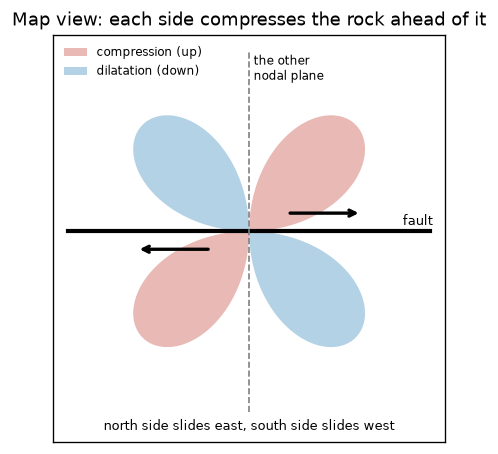

In [2]:
phi = np.linspace(0, 2 * np.pi, 721)                                   # directions in map view
Rm = np.sin(2 * phi)                                                    # 2 (gamma.n)(gamma.s), n north, s east
fig, ax = plt.subplots(figsize=(4.4, 4.4))
for sign, col, name in ((1, "#c0392b", "compression (up)"), (-1, "#2980b9", "dilatation (down)")):
    r = np.where(sign * Rm > 0, np.abs(Rm), 0)
    ax.fill(r * np.sin(phi), r * np.cos(phi), color=col, alpha=0.35, lw=0, label=name)
ax.plot([-1.2, 1.2], [0, 0], color="k", lw=2.5)                        # the fault, running east-west
ax.plot([0, 0], [-1.2, 1.2], color="0.5", lw=1, ls="--")                # the other nodal plane
ax.annotate("", xy=(0.75, 0.12), xytext=(0.25, 0.12), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(-0.75, -0.12), xytext=(-0.25, -0.12), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(1.22, 0.02, "fault", fontsize=8, va="bottom", ha="right")
ax.text(0.03, 1.18, "the other\nnodal plane", fontsize=7, va="top")
ax.text(0, -1.32, "north side slides east, south side slides west", fontsize=8, ha="center")
ax.set(xlim=(-1.3, 1.3), ylim=(-1.4, 1.3), xticks=[], yticks=[], aspect="equal",
       title="Map view: each side compresses the rock ahead of it")
ax.legend(fontsize=7, frameon=False, loc="upper left")
ax.grid(False)
plt.show()


**4. The moment tensor.** The radiation of step 3 can be written with a matrix. Since
$(\gamma\cdot\mathbf n)(\gamma\cdot\mathbf s) = \gamma^\top(\mathbf n\,\mathbf s^\top)\gamma$,

$$R(\gamma) \;=\; \gamma^\top M\,\gamma, \qquad M = M_0\,(\mathbf n\,\mathbf s^\top + \mathbf s\,\mathbf n^\top) .$$

$M$ is the **moment tensor** (Gilbert, 1971), a symmetric $3\times3$ matrix. Slip on a fault gives
this particular $M$, the **double couple**; other point sources give other symmetric matrices, and
for every one of them the P radiation is $\gamma^\top M\gamma$. An **explosion**, for example, pushes
outward equally in every direction: $M = I$, so $R = 1$ everywhere, and every station records a
compression.

**5. One ray, one row.** Write the six independent entries of $M$ as a vector,

$$M = \begin{bmatrix} M_{xx} & M_{xy} & M_{xz} \\ M_{xy} & M_{yy} & M_{yz} \\
M_{xz} & M_{yz} & M_{zz}\end{bmatrix}, \qquad
m = \begin{bmatrix}M_{xx} & M_{yy} & M_{zz} & M_{xy} & M_{xz} & M_{yz}\end{bmatrix}^\top .$$

$\gamma^\top M\gamma$ is a quadratic form in $\gamma$ but it is **linear in $M$**: double the moment
tensor and the amplitude doubles. Multiplied out, it is a dot product:

$$\gamma^\top M\gamma = \gamma_x^2 M_{xx} + \gamma_y^2 M_{yy} + \gamma_z^2 M_{zz}
+ 2\gamma_x\gamma_y M_{xy} + 2\gamma_x\gamma_z M_{xz} + 2\gamma_y\gamma_z M_{yz}
\;=\; g(\gamma)^\top m ,$$

with $g(\gamma) = [\gamma_x^2,\ \gamma_y^2,\ \gamma_z^2,\ 2\gamma_x\gamma_y,\ 2\gamma_x\gamma_z,\
2\gamma_y\gamma_z]^\top$. Stack one row per station and you have a design matrix $G$, exactly as in
Session 1 — only now the columns are ray geometry rather than magnitude and distance.

Three approximations were made along the way: the fault is small compared with the wavelength
(a **point source**), the station is many wavelengths away (the **far field**), and the pulse has
the same shape at every station, so that only its size and sign differ.


In [3]:
def ray_rows(azimuth, takeoff):
    """One row of the design matrix per ray, so that the P amplitude is `row @ m`.

    `m` is [Mxx, Myy, Mzz, Mxy, Mxz, Myz] in north-east-down. `azimuth` is degrees east of north
    and `takeoff` is degrees from the downward vertical, which is how the archive reports them.
    """
    a, i = np.radians(azimuth), np.radians(takeoff)
    g = np.stack([np.sin(i) * np.cos(a), np.sin(i) * np.sin(a), np.cos(i)], axis=-1)
    return np.stack([g[..., 0] ** 2, g[..., 1] ** 2, g[..., 2] ** 2,
                     2 * g[..., 0] * g[..., 1], 2 * g[..., 0] * g[..., 2],
                     2 * g[..., 1] * g[..., 2]], axis=-1)


# the check that matters: the row really is the quadratic form, for random rays
az, ih = rng.uniform(0, 360, 5), rng.uniform(1, 179, 5)
M_test = sdr_to_mt(140.0, 75.0, -140.0)
g = np.stack([np.sin(np.radians(ih)) * np.cos(np.radians(az)),
              np.sin(np.radians(ih)) * np.sin(np.radians(az)), np.cos(np.radians(ih))], axis=1)
direct = np.einsum("ij,jk,ik->i", g, M_test, g)
print("largest difference between `ray_rows @ m` and gamma^T M gamma:",
      f"{np.abs(ray_rows(az, ih) @ mt_to_vec(M_test) - direct).max():.2e}")


largest difference between `ray_rows @ m` and gamma^T M gamma: 2.22e-16


#### Optional: the exact far-field formula

In uniform rock of density $\rho$ and P-wave speed $\alpha$, rays are straight, and the P wave of a
point source at distance $r$ is (Aki & Richards, 2002, eq. 4.29, its far-field P term)

$$\mathbf u(t) \;=\; \frac{\gamma^\top \dot M(t - r/\alpha)\,\gamma}{4\pi\rho\alpha^3 r}\;\gamma ,$$

where $\dot M$ is the rate of change of the moment tensor. The numerator is step 4's radiation. The
final $\gamma$ says the ground moves along the ray, as a P wave must; $t - r/\alpha$ is the travel-time
delay; and $1/(4\pi\rho\alpha^3 r)$ is the positive path factor for uniform rock. For an earthquake
$\dot M(t) = \dot M_0(t)\,\hat M$: one pulse shape, the **moment rate**, the same at every station,
times a fixed pattern $\hat M$ — the third approximation above. The same formula has an S term, with
the S speed $\beta$ in place of $\alpha$; A.11 uses it.


#### A synthetic test: a known mechanism

A double couple is usually described by three angles instead of by $\mathbf n$ and $\mathbf s$: the
**strike** of the fault (the compass direction of its trace, with the fault dipping to the right),
the **dip** (how steeply it leans, 90° for vertical), and the **rake** (which way the upper block
slid, measured in the fault plane from the strike direction). `sdr_to_mt` turns those three angles
into the six numbers. Slip on a plane changes no volume, so the tensor's **isotropic part** (its
trace, the part that would push outward equally in every direction, like the explosion of step 4)
is zero.

For the planted truth we take a real mechanism: the one the network published for the largest
earthquake The Geysers has ever had, which Part B inverts from its own recordings. Strike 335°,
dip 83°, rake −165° — a nearly vertical fault slipping nearly horizontally.

For the station geometry we take the same earthquake's own rays: the azimuth and take-off angle
the network computed for every station that recorded it, read straight out of the archive. So the
planted world of Part A is the real one Part B will meet, with only the source made known to us.


In [4]:
TRUTH = (335.0, 83.0, -165.0)             # strike, dip, rake of the planted double couple
M_true = sdr_to_mt(*TRUTH)
m_true = mt_to_vec(M_true)
print("the planted moment tensor, in north-east-down (unit moment):")
print(np.round(M_true, 3))
print("\nits trace (the isotropic part):", f"{np.trace(M_true):+.2e}", " -- slip on a plane has none")
print("its two nodal planes:", sdr(M_true, 0), "and", sdr(M_true, 1))


the planted moment tensor, in north-east-down (unit moment):
[[-0.723 -0.592  0.213]
 [-0.592  0.786  0.178]
 [ 0.213  0.178 -0.063]]

its trace (the isotropic part): -1.39e-17  -- slip on a plane has none
its two nodal planes: (243, 75, -7) and (335, 83, -165)


In [5]:
from geysers_data import polarities

EVENT = "nc72737985"                       # the Mw 5.0 of 14 December 2016, which Part B inverts
_rays = polarities().query("event_id == @EVENT").sort_values("station")
AZ, IH = _rays.azimuth.to_numpy(), _rays.takeoff_angle.to_numpy()
G = ray_rows(AZ, IH)
d_clean = G @ m_true
print(f"{EVENT}: {len(AZ)} stations recorded it, at "
      f"{_rays.distance_km.min():.1f}-{_rays.distance_km.max():.1f} km;  G is {G.shape[0]} x {G.shape[1]}")
print(f"azimuths cover {AZ.min():.0f}-{AZ.max():.0f} deg, take-off angles {IH.min():.0f}-{IH.max():.0f} deg")
print(f"amplitudes run {d_clean.min():+.3f} to {d_clean.max():+.3f};  "
      f"{(d_clean > 0).sum()} rays are compressional and {(d_clean < 0).sum()} dilatational")


nc72737985: 41 stations recorded it, at 1.5-28.8 km;  G is 41 x 6
azimuths cover 15-342 deg, take-off angles 67-145 deg
amplitudes run -0.992 to +0.974;  33 rays are compressional and 8 dilatational


#### The focal sphere, and the two kinds of data

The natural picture of the rays is the **focal sphere**: a small sphere drawn around the source,
with each ray plotted where it leaves. Seismologists show its lower half, with a ray that went
upward plotted at the point diametrically opposite, so that everything fits on one disc
(an **equal-area** projection keeps areas honest). The two **nodal planes** of a double couple cut
the disc into four quadrants: in two the ground first moves away from the source (compression, an
*up* first motion at the station), in the other two towards it (dilatation, *down*).

Drawn on it, the same 41 rays carry two different kinds of data. Colour a ray by its amplitude
$g(\gamma)^\top m$ and you have a **regression** target, one number per ray. Keep only the sign and
you have a **classification** label, $+1$ or $-1$. The design matrix $G$ is the same for both.


In [6]:
def focal_xy(azimuth, takeoff):
    """Equal-area lower-hemisphere coordinates, with up-going rays reflected through the origin."""
    az, ih = np.asarray(azimuth, float) % 360, np.asarray(takeoff, float)
    up = ih > 90
    az = np.where(up, az + 180, az) % 360
    ih = np.where(up, 180 - ih, ih)
    r = np.sqrt(2) * np.sin(np.radians(ih) / 2)
    return r * np.sin(np.radians(az)), r * np.cos(np.radians(az))


def plane_xy(strike, dip, n=181):
    """The trace of one nodal plane on the focal sphere.

    The plane is spanned by its strike direction and its down-dip direction, so sweeping an angle
    through that pair walks right round it. Points on the upper half are reflected through the
    origin, which is what puts the whole plane on the lower-hemisphere disc.
    """
    f, d = np.radians(strike), np.radians(dip)
    along = np.array([np.cos(f), np.sin(f), 0.0])
    down = np.array([-np.cos(d) * np.sin(f), np.cos(d) * np.cos(f), np.sin(d)])
    t = np.linspace(0, 2 * np.pi, n)[:, None]
    v = np.cos(t) * along + np.sin(t) * down
    v = np.where(v[:, [2]] < 0, -v, v)                     # keep the lower hemisphere
    return focal_xy(np.degrees(np.arctan2(v[:, 1], v[:, 0])),
                    np.degrees(np.arccos(np.clip(v[:, 2], -1, 1))))


def focal_sphere(ax, M, color="#2c3e50", lw=1.2, ls="-"):
    """Draw both nodal planes of M on a focal sphere."""
    for strike, dip, _ in nodal_planes(M):
        px, py = plane_xy(strike, dip)
        cut = np.where(np.abs(np.diff(px)) + np.abs(np.diff(py)) > 0.5)[0] + 1   # trace crosses the rim
        ax.plot(np.insert(px, cut, np.nan), np.insert(py, cut, np.nan), color=color, lw=lw, ls=ls)
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color="0.4", lw=1))
    ax.set(xlim=(-1.15, 1.15), ylim=(-1.15, 1.15), xticks=[], yticks=[])
    ax.set_aspect("equal")
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)


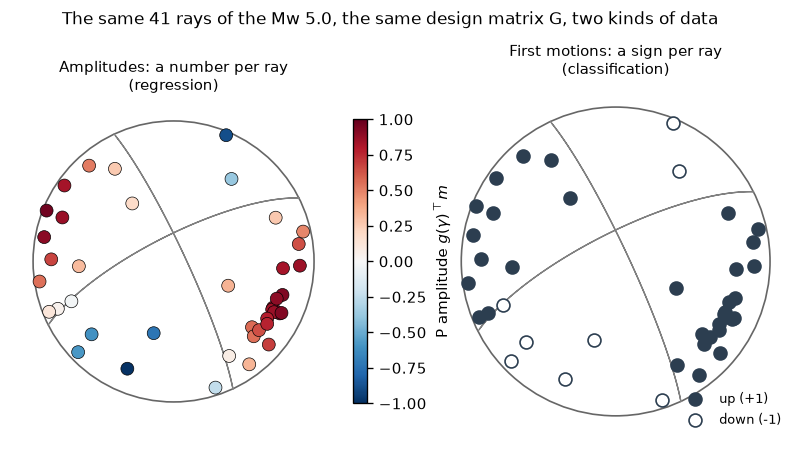

In [7]:
x_ray, y_ray = focal_xy(AZ, IH)
fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.3))
focal_sphere(axes[0], M_true, color="0.5", lw=0.8)
sc = axes[0].scatter(x_ray, y_ray, c=d_clean, cmap="RdBu_r", vmin=-1, vmax=1, s=60,
                     edgecolors="k", linewidths=0.4, zorder=3)
fig.colorbar(sc, ax=axes[0], fraction=0.04, label=r"P amplitude $g(\gamma)^\top m$")
axes[0].set_title("Amplitudes: a number per ray\n(regression)", fontsize=9)
focal_sphere(axes[1], M_true, color="0.5", lw=0.8)
up = d_clean > 0
axes[1].scatter(x_ray[up], y_ray[up], s=60, c="#2c3e50", zorder=3, label="up (+1)")
axes[1].scatter(x_ray[~up], y_ray[~up], s=60, facecolors="white", edgecolors="#2c3e50", zorder=3,
                label="down (-1)")
axes[1].legend(fontsize=8, loc="lower right", frameon=False)
axes[1].set_title("First motions: a sign per ray\n(classification)", fontsize=9)
fig.suptitle(f"The same {len(AZ)} rays of the Mw 5.0, the same design matrix G, two kinds of data", fontsize=10)
plt.show()


### A.2 · Least squares, again

Give the amplitudes a little noise and solve. The normal equations are the same ones Session 1 used,
$G^\top G\,\hat m = G^\top d$, and `np.linalg.lstsq` solves them:

$$\hat m = (G^\top G)^{-1}G^\top d .$$

Nothing about the derivation changes because the unknowns are now a moment tensor. What changes is
what we can ask of the answer, because here — unlike any real inversion — we know $m$.


In [8]:
NOISE = 0.05 * np.abs(d_clean).max()               # 5 % of the largest amplitude
d_obs = d_clean + rng.normal(0, NOISE, len(d_clean))
m_hat = np.linalg.lstsq(G, d_obs, rcond=None)[0]

print("             ", "  ".join(f"{n:>8s}" for n in ("Mxx", "Myy", "Mzz", "Mxy", "Mxz", "Myz")))
print("truth        ", "  ".join(f"{v:8.3f}" for v in m_true))
print("least squares", "  ".join(f"{v:8.3f}" for v in m_hat))
print(f"\nlargest error in any component: {np.abs(m_hat - m_true).max():.3f}")
print("recovered nodal planes:", sdr(vec_to_mt(m_hat), 0), "and", sdr(vec_to_mt(m_hat), 1))
print(f"Kagan angle to the truth: {kagan(vec_to_mt(m_hat), M_true):.1f} deg")


                   Mxx       Myy       Mzz       Mxy       Mxz       Myz
truth           -0.723     0.786    -0.063    -0.592     0.213     0.178
least squares   -0.711     0.804    -0.131    -0.603     0.197     0.182

largest error in any component: 0.069
recovered nodal planes: (335, 83, -165) and (243, 75, -8)
Kagan angle to the truth: 0.6 deg


The **Kagan angle** is how seismologists say "how far apart are these two mechanisms": the smallest
rotation that carries one onto the other. It runs from 0° to 120°, and it is the number every
comparison in this session reports. Two solutions agreeing to a few degrees are the same answer;
60° is a different earthquake.

With 41 well-spread rays and 5 % noise, least squares recovers the planted tensor almost exactly —
under a degree. That will not last.


### A.3 · The SVD: what the data determine, and what they do not

$(G^\top G)^{-1}$ exists only if $G$ has six independent columns. Whether it does — and how close it
comes to not — is read off the **singular value decomposition**

$$G = U\Sigma V^\top ,$$

with $U$ and $V$ orthogonal and $\Sigma$ diagonal, holding the **singular values**
$\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_6 \ge 0$. The columns of $V$ are directions in *model*
space: combinations of the six moment-tensor components. The columns of $U$ are directions in
*data* space. The decomposition says that $G$ does one simple thing — it takes the model direction
$v_j$, stretches it by $\sigma_j$, and puts it along the data direction $u_j$.

Everything follows from that.

- If $\sigma_j = 0$, the model direction $v_j$ produces **no data at all**. It is in the **null
  space**: you can add any amount of it to the answer and no instrument would notice.
- If $\sigma_j$ is small but not zero, $v_j$ produces a little data. Noise of the same size is
  indistinguishable from it, so it is determined badly. The least-squares solution divides by
  $\sigma_j$, so the noise comes back **amplified by $1/\sigma_j$**.
- The ratio $\sigma_1/\sigma_6$ is the **condition number**. It says how much the worst-determined
  combination is worse off than the best.


In [9]:
U, S, Vt = np.linalg.svd(G, full_matrices=False)
print("singular values, divided by the largest:", np.round(S / S[0], 3))
print(f"condition number: {S[0] / S[-1]:.1f}")
print("\nthe worst-determined combination of the six components:")
print("   ", "  ".join(f"{n} {v:+.2f}" for n, v in
                       zip(("Mxx", "Myy", "Mzz", "Mxy", "Mxz", "Myz"), Vt[-1])))


singular values, divided by the largest: [1.    0.685 0.516 0.423 0.343 0.193]
condition number: 5.2

the worst-determined combination of the six components:
    Mxx -0.20  Myy -0.07  Mzz +0.98  Mxy +0.00  Mxz +0.06  Myz -0.03


A condition number of about 5 is comfortable: the worst direction is only five times harder than
the best. The worst direction is almost pure $M_{zz}$, a first hint of A.4. Now break it. Seismologists meet a null space when the
stations are badly placed. This earthquake is shallow — about 1.5 km down — and most stations are
many kilometres away, so most rays leave the source close to horizontal: the take-off angles
cluster around 90°. Squeeze them further towards 90°, as for a shallow source seen only by distant
stations, and watch the singular values collapse.


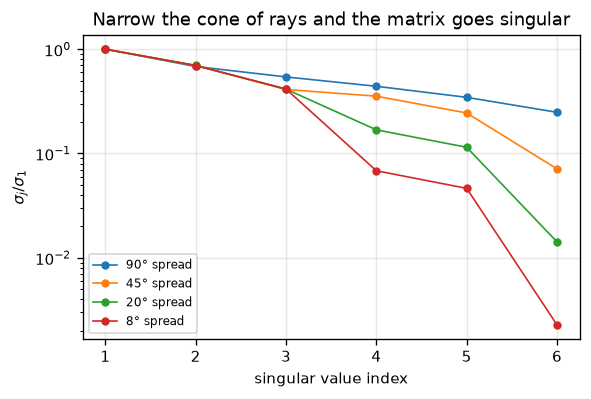

In [10]:
fig, ax0 = plt.subplots(figsize=(5.0, 3.4))
for c in (90, 45, 20, 8):
    ih_cone = 90 + (IH - IH.mean()) * c / (IH.max() - IH.min())
    sv = np.linalg.svd(ray_rows(AZ, ih_cone), compute_uv=False)
    ax0.semilogy(range(1, 7), sv / sv[0], "o-", lw=1, ms=4, label=f"{c}° spread")
ax0.set(xlabel="singular value index", ylabel=r"$\sigma_j/\sigma_1$",
        title="Narrow the cone of rays and the matrix goes singular")
ax0.legend(fontsize=7)
fig.tight_layout()
plt.show()


In [11]:
spreads = np.linspace(4, 90, 30)
lo, mid, hi, conds = [], [], [], []
for c in spreads:
    ih_cone = 90 + (IH - IH.mean()) * c / (IH.max() - IH.min())
    Gc = ray_rows(AZ, ih_cone)
    k = [kagan(vec_to_mt(np.linalg.lstsq(Gc, Gc @ m_true + rng.normal(0, NOISE, len(AZ)),
                                         rcond=None)[0]), M_true) for _ in range(60)]
    lo.append(np.percentile(k, 25)); mid.append(np.median(k)); hi.append(np.percentile(k, 75))
    conds.append(np.linalg.cond(Gc))


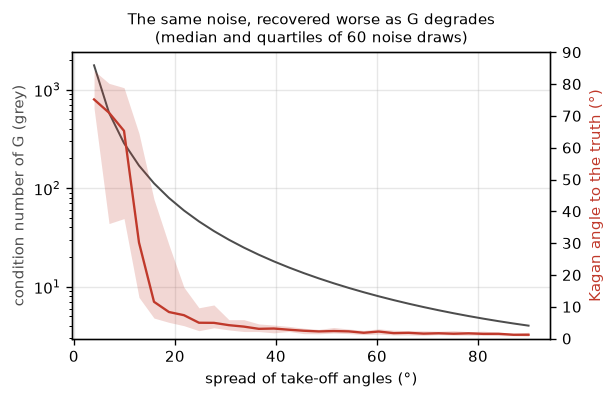

Kagan angle to the truth, median of 60 noise draws:
   take-off spread   4.0° ->  75.2°
   take-off spread  24.8° ->   5.0°
   take-off spread  45.5° ->   2.5°
   take-off spread  66.3° ->   1.8°
   take-off spread  87.0° ->   1.2°


In [12]:
fig2, ax2 = plt.subplots(figsize=(5.2, 3.4))
ax2.semilogy(spreads, conds, color="0.3", lw=1.2, label="condition number")
ax2.set(xlabel="spread of take-off angles (°)")
ax2.set_ylabel("condition number of G (grey)", color="0.3")
ax3 = ax2.twinx()
ax3.fill_between(spreads, lo, hi, color="#c0392b", alpha=0.2, lw=0)
ax3.plot(spreads, mid, color="#c0392b", lw=1.4)
ax3.set_ylabel("Kagan angle to the truth (°)", color="#c0392b")
ax3.set_ylim(0, 90)
ax3.grid(False)
ax2.set_title("The same noise, recovered worse as G degrades\n"
              "(median and quartiles of 60 noise draws)", fontsize=9)
fig2.tight_layout()
plt.show()
print("Kagan angle to the truth, median of 60 noise draws:")
for c, k in zip(spreads[::7], np.array(mid)[::7]):
    print(f"   take-off spread {c:5.1f}° -> {k:5.1f}°")


The two curves are the same statement twice. As the rays crowd into one direction the smallest
singular value falls, the condition number rises, and the *same* 5 % noise turns a perfect recovery
into a mechanism tens of degrees away from the truth. Nothing about the data got noisier; the
geometry stopped separating the six numbers.

**Exercise 1.** The null direction is not an abstraction: you can add it to the answer and the
predicted data barely move. Take the narrow-cone matrix `G_cone` below, get its last right singular
vector `v6` from `np.linalg.svd`, and print two things: the largest change in the predicted
amplitudes when `m_true + 2 * v6` is used instead of `m_true`, and the Kagan angle between the two
mechanisms. One should be tiny and the other should not.


In [13]:
ih_narrow = 90 + (IH - IH.mean()) * 8 / (IH.max() - IH.min())
G_cone = ray_rows(AZ, ih_narrow)


In [14]:
v6 = np.linalg.svd(G_cone, full_matrices=False)[2][-1]
m_shifted = m_true + 2.0 * v6
print(f"largest change in the predicted amplitudes: {np.abs(G_cone @ m_shifted - G_cone @ m_true).max():.2e}")
print(f"largest amplitude itself:                   {np.abs(G_cone @ m_true).max():.2e}")
print(f"the change as a share of it:                {np.abs(G_cone @ (m_shifted - m_true)).max() / np.abs(G_cone @ m_true).max():.1%}")
print(f"Kagan angle between the two mechanisms:     {kagan(vec_to_mt(m_shifted), M_true):.1f} deg")


largest change in the predicted amplitudes: 1.54e-02
largest amplitude itself:                   9.96e-01
the change as a share of it:                1.6%
Kagan angle between the two mechanisms:     62.5 deg


A mechanism tens of degrees away that predicts nearly the same data — a change of about 1.6 % of
the largest amplitude, well below the 5 % noise. No amount of care with the fitting can separate
those two, because the difference between them was never recorded above the noise. This is the single
most important fact about inverse problems, and it is why the rest of the session is about what the
data leave undetermined rather than about how well they are fitted.


### A.4 · Resolution: the answer is a blurred version of the truth

Suppose we keep only the model directions the data see well, dropping the ones with small singular
values. Keeping the first $p$ gives the **truncated** solution

$$\hat m = V_p\Sigma_p^{-1}U_p^\top d .$$

Substitute the noiseless data $d = Gm_{\text{true}}$ and the model drops out:

$$\hat m = V_p V_p^\top \, m_{\text{true}} \;=\; R\, m_{\text{true}} .$$

$R = V_pV_p^\top$ is the **resolution matrix**. It says that even with perfect data the inversion
does not return the truth: it returns the truth seen through $R$. If $R$ is the identity, every
component is resolved. Where it is not, each recovered component is a blend of several true ones,
and row $j$ of $R$ says exactly which blend.

The honest way to read a resolution matrix is a **spike test**: put all the moment into one
component, invert with perfect data, and look at what comes back.

One caution before reading it. Keep all six directions and $R$ is the identity for every geometry
here, since none has a singular value of exactly zero; the price is A.3's noise amplification in
the weak directions. So $R$ describes a *choice* as well as the rays. Here we keep the four
best-determined directions and discard the two weakest, which is what damping will do smoothly in
A.5, and ask which components are lost first.


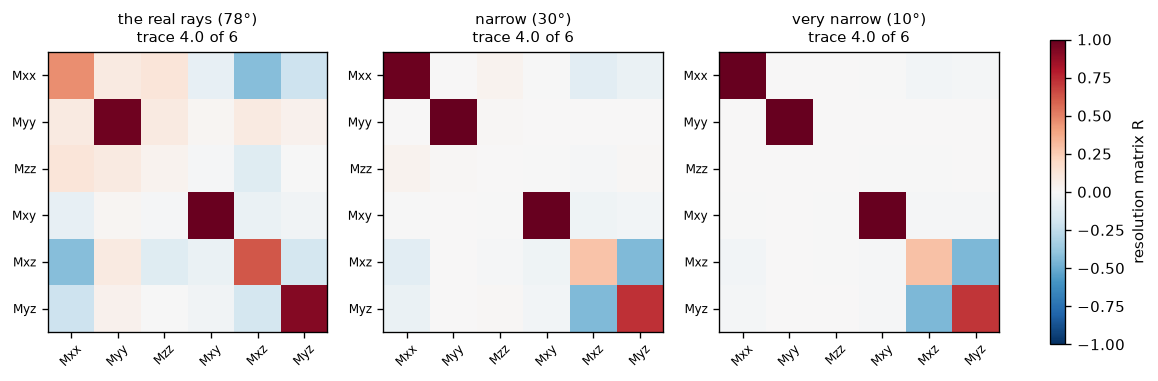

In [15]:
labels = ("Mxx", "Myy", "Mzz", "Mxy", "Mxz", "Myz")
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
SPREAD = int(round(IH.max() - IH.min()))       # the real rays' spread of take-off angles
for ax, (c, name) in zip(axes, ((SPREAD, f"the real rays ({SPREAD}°)"), (30, "narrow (30°)"), (10, "very narrow (10°)"))):
    ih_c = 90 + (IH - IH.mean()) * c / (IH.max() - IH.min())
    Vc = np.linalg.svd(ray_rows(AZ, ih_c), full_matrices=False)[2]
    R = Vc[:4].T @ Vc[:4]                       # keep the four best-determined directions
    im = ax.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(6), labels, fontsize=7, rotation=45)
    ax.set_yticks(range(6), labels, fontsize=7)
    ax.set_title(f"{name}\ntrace {np.trace(R):.1f} of 6", fontsize=9)
    ax.grid(False)
fig.colorbar(im, ax=axes, label="resolution matrix R", fraction=0.02)
plt.show()


In [16]:
print("how much of each component survives the inversion (the diagonal of R):")
print("   spread  " + "  ".join(f"{n:>5s}" for n in labels))
for c in (SPREAD, 30, 10):
    ih_c = 90 + (IH - IH.mean()) * c / (IH.max() - IH.min())
    Vc = np.linalg.svd(ray_rows(AZ, ih_c), full_matrices=False)[2]
    R = Vc[:4].T @ Vc[:4]
    print(f"   {c:4d}°   " + "  ".join(f"{v:5.2f}" for v in np.diag(R)))

for j, name in ((3, "Mxy"), (2, "Mzz")):
    spike = np.zeros(6)
    spike[j] = 1.0
    for c in (SPREAD, 10):
        ih_c = 90 + (IH - IH.mean()) * c / (IH.max() - IH.min())
        Vc = np.linalg.svd(ray_rows(AZ, ih_c), full_matrices=False)[2]
        got = (Vc[:4].T @ Vc[:4]) @ spike
        print(f"spread {c:3d}°: a pure {name} comes back as  " +
              "  ".join(f"{n} {v:+.2f}" for n, v in zip(labels, got)))


how much of each component survives the inversion (the diagonal of R):
   spread    Mxx    Myy    Mzz    Mxy    Mxz    Myz
     78°    0.47   0.97   0.04   0.99   0.62   0.92
     30°    0.98   1.00   0.00   1.00   0.29   0.73
     10°    1.00   1.00   0.00   1.00   0.29   0.71
spread  78°: a pure Mxy comes back as  Mxx -0.08  Myy +0.02  Mzz -0.01  Mxy +0.99  Mxz -0.07  Myz -0.03
spread  10°: a pure Mxy comes back as  Mxx -0.00  Myy +0.00  Mzz -0.00  Mxy +1.00  Mxz -0.02  Myz -0.01
spread  78°: a pure Mzz comes back as  Mxx +0.12  Myy +0.09  Mzz +0.04  Mxy -0.01  Mxz -0.12  Myz -0.01
spread  10°: a pure Mzz comes back as  Mxx +0.00  Myy +0.00  Mzz +0.00  Mxy -0.00  Mxz -0.00  Myz +0.01


Keeping four of six directions means $R$ has trace 4 whatever the geometry: the inversion always
returns four independent things. What changes is **which** four.

With the real rays the four are shared out: $M_{yy}$, $M_{xy}$ and $M_{yz}$ come back almost
whole, $M_{xz}$ mostly, $M_{xx}$ less than a third, and $M_{zz}$ hardly at all. As the cone
narrows, $R$ turns starker: $M_{xx}$, $M_{yy}$ and $M_{xy}$ go to 1.00, $M_{xz}$ and $M_{yz}$ keep
only part of themselves, and $M_{zz}$ goes to 0.00. That last one is not recovered badly. It is
**not recovered at all**, and whatever the inversion prints for it came from the prior rather than
from the data.

The two spikes show both halves: a pure $M_{xy}$ comes back as itself, a pure $M_{zz}$ comes back as
almost nothing. The reason is in the row $g(\gamma)$ of A.1: $M_{zz}$ enters every amplitude
multiplied by $\gamma_z^2$, the square of the ray's vertical component, and a ray leaving close to
horizontal has $\gamma_z$ near zero. A shallow source recorded by stations at distances large
compared with its depth sends nearly all its rays out that way, so its **vertical component
$M_{zz}$ is the hardest thing in the tensor to determine**. (Rays leaving steeply — a deep source
under a small network — would reverse the roles, resolving $M_{zz}$ and losing the horizontal
components.) Worth remembering when Part B reports an isotropic component, which also lives
partly in $M_{zz}$.

Resolution is a property of $G$ alone. It does not involve the data, the noise, or the answer. You
can compute it **before the earthquake happens**, for a network that does not yet exist.


### A.5 · Damping is a prior, and it acts where the data are quiet

When $G$ is badly conditioned, least squares divides by small singular values and the noise blows
up. The standard repair is to ask for a small answer as well as a fitting one: minimise

$$\|d - Gm\|^2 \;+\; \lambda^2\|m\|^2 .$$

In seismology this is called **damping**; in Session 1 it was **ridge regression**, the most probable
answer under a Gaussian prior that expects $m$ to be small. The number $\lambda$ is the noise level in
the data divided by the size the prior expects the answer to have. Same formula, same meaning: *the
answer should not be large unless the data insist*.

**Where the data insist.** Recall the SVD from A.3, $G = U\Sigma V^\top$:

- $V$ is $6\times6$. Its columns $v_j$ are unit vectors at right angles to each other, so
  $V^\top V = VV^\top = I$: multiplying by $V^\top$ is a **rotation** of model space, and multiplying
  by $V$ turns it back.
- $U$ has one row per station. Its columns $u_j$ are unit vectors at right angles too, so
  $U^\top U = I$.
- $\Sigma$ is diagonal, holding the singular values $\sigma_1 \ge \dots \ge \sigma_6$.

**Step 1: rotate the model.** Let $c = V^\top m$: the same six numbers as $m$, measured along the
columns of $V$ instead of along $M_{xx}, \dots, M_{yz}$. Nothing is lost, because $Vc = VV^\top m = m$.
(The cell below prints two columns of $V$, and $m$ and $c$ for A.1's known mechanism.)

**Step 2: rotate the data.** Put $G = U\Sigma V^\top$ into $d = Gm + e$, where $e$ is the noise:

$$d \;=\; U\Sigma\, c \;+\; e .$$

Multiply on the left by $U^\top$, and use $U^\top U = I$:

$$U^\top d \;=\; \Sigma\, c \;+\; U^\top e .$$

**Step 3: read it row by row.** $\Sigma$ is diagonal, so row $j$ contains only $c_j$:

$$u_j^\top d \;=\; \sigma_j\, c_j \;+\; e_j , \qquad e_j = u_j^\top e .$$

Six equations, each with one unknown. Row $j$ is one number $c_j$ measured through a gain $\sigma_j$,
plus noise: **six instruments of different sensitivity, each measuring one thing.**


In [17]:
Uc, Sc, Vtc = np.linalg.svd(G, full_matrices=False)
for j in (0, 5):
    print(f"column v_{j + 1} of V (singular value {Sc[j] / Sc[0]:.2f} of the largest) =  " +
          " ".join(f"{v:+.2f} {n}" for v, n in zip(Vtc[j], labels)))
c = Vtc @ m_true
print("\nA.1's known mechanism:  m =", np.round(m_true, 2))
print("rotated,         c = V^T m =", np.round(c, 2))
print(f"rotated back, V c differs from m by at most {np.abs(Vtc.T @ c - m_true).max():.1e}")


column v_1 of V (singular value 1.00 of the largest) =  -0.24 Mxx -0.62 Myy -0.12 Mzz +0.62 Mxy +0.20 Mxz -0.35 Myz
column v_6 of V (singular value 0.19 of the largest) =  -0.20 Mxx -0.07 Myy +0.98 Mzz +0.00 Mxy +0.06 Mxz -0.03 Myz

A.1's known mechanism:  m = [-0.72  0.79 -0.06 -0.59  0.21  0.18]
rotated,         c = V^T m = [-0.69  0.01  0.19 -0.89 -0.52  0.03]
rotated back, V c differs from m by at most 2.2e-16


The best-measured direction $v_1$ mixes several components; the worst-measured, $v_6$, is almost
pure $M_{zz}$ — which is why A.4 found $M_{zz}$ the hardest component to recover.

**Step 4: the objective splits the same way.** A rotation changes no lengths, so $\|m\|^2 = \|c\|^2$
$= \sum_j c_j^2$. The misfit $\|d - U\Sigma c\|^2$ is $\sum_j (u_j^\top d - \sigma_j c_j)^2$ plus the
part of $d$ that lies outside the columns of $U$ — data no source can produce, the same whatever
$c$ is. So the objective is a sum of six terms with one unknown each,

$$\sum_j \Big[(u_j^\top d - \sigma_j c_j)^2 + \lambda^2 c_j^2\Big] \;+\; \text{a constant},$$

and each $c_j$ can be found on its own. Setting the derivative of term $j$ to zero,
$-2\sigma_j (u_j^\top d - \sigma_j c_j) + 2\lambda^2 c_j = 0$, gives

$$\hat c_j \;=\; f_j\,\frac{u_j^\top d}{\sigma_j}, \qquad f_j \;=\; \frac{\sigma_j^2}{\sigma_j^2 + \lambda^2} .$$

Without damping, $f_j = 1$: least squares divides each reading by its gain, so an insensitive
instrument, small $\sigma_j$, has its noise magnified most — A.3's noise amplification. Damping
multiplies by the **filter factor** $f_j$: near 1 for a sensitive instrument ($\sigma_j \gg \lambda$),
whose reading is kept, and near 0 for an insensitive one ($\sigma_j \ll \lambda$), whose reading is
set aside so that its coordinate stays at the prior, zero. Rotating back gives the damped answer,
$\hat m = V\hat c$. **Damping leaves the well-measured directions alone and pulls the
poorly measured ones towards the prior.**


#### The bias–variance trade-off

How much damping is right? Take one of the six coordinates and drop the index $j$. Dividing its
reading, $u^\top d = \sigma c + e$, by the gain gives the least-squares estimate

$$\frac{u^\top d}{\sigma} \;=\; c \;+\; \frac{e}{\sigma} :$$

the truth plus noise. The noise $e$ is different in every repeat of the experiment; it averages to
zero, and its standard deviation is the data's noise level $\sigma_d$ (so the average of $e^2$ is
$\sigma_d^2$). After dividing by the gain, the noise has standard deviation $\sigma_d/\sigma$ — large
when $\sigma$ is small. Damping multiplies the estimate by $f$, a number between 0 and 1:

$$\hat c \;=\; f\,\Big(c + \frac{e}{\sigma}\Big) \;=\; f c \;+\; f\,\frac{e}{\sigma} .$$

The first part, $fc$, is the same in every repeat; the second is the noise, shrunk by $f$. Repeat the
experiment many times, with fresh noise each time, and look at where the answers land.


least squares, f = 1  : answers centre on +1.00 (bias +0.00), spread 1.00;  average squared error 0.99
damped, f = 0.5       : answers centre on +0.50 (bias -0.50), spread 0.50;  average squared error 0.50


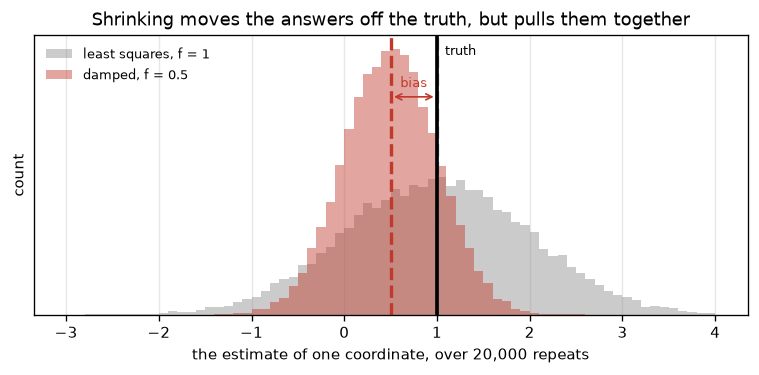

In [18]:
c_true, noise = 1.0, 1.0                         # the true coordinate, and the noise sigma_d / sigma
c_ls = c_true + np.random.default_rng(3).normal(0, noise, 20000)   # 20,000 least-squares estimates

fig, ax = plt.subplots(figsize=(6.4, 3.2))
bins = np.linspace(-3, 4, 71)
for f, col, name in ((1.0, "0.55", "least squares, f = 1"), (0.5, "#c0392b", "damped, f = 0.5")):
    ax.hist(f * c_ls, bins=bins, histtype="stepfilled", alpha=0.45, color=col, label=name)
    ax.axvline(f * c_true, color=col, lw=2, ls="--")
    print(f"{name:22s}: answers centre on {np.mean(f * c_ls):+.2f} (bias {np.mean(f * c_ls) - c_true:+.2f}), "
          f"spread {np.std(f * c_ls):.2f};  average squared error {np.mean((f * c_ls - c_true) ** 2):.2f}")
ax.axvline(c_true, color="k", lw=2.2)
ax.text(c_true, ax.get_ylim()[1] * 0.93, "  truth", fontsize=8)
y_arrow = ax.get_ylim()[1] * 0.78
ax.annotate("", xy=(0.5 * c_true, y_arrow), xytext=(c_true, y_arrow),
            arrowprops=dict(arrowstyle="<->", color="#c0392b"))
ax.text(0.75 * c_true, y_arrow * 1.03, "bias", color="#c0392b", fontsize=8, ha="center", va="bottom")
ax.set(xlabel="the estimate of one coordinate, over 20,000 repeats", ylabel="count", yticks=[],
       title="Shrinking moves the answers off the truth, but pulls them together")
ax.legend(fontsize=8, frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


Here the true coordinate and the noise are both 1. Least squares is right **on average** — its
answers centre on the truth — but they are spread widely. The damped answers are wrong on average,
centred on $0.5\,c$, but spread half as much. From $\hat c = fc + fe/\sigma$:

**Its average.** $e$ averages to zero, so $\hat c$ averages to $fc$, and misses the truth by
$fc - c = -(1-f)\,c$. That miss is the **bias**: an error that no amount of repeating removes.

**Its scatter.** About that average, $\hat c$ moves by $fe/\sigma$ from repeat to repeat. The average of
the square of that scatter is the **variance**, $f^2\sigma_d^2/\sigma^2$.

**Its error.** In one repeat the error is the miss plus the scatter, $\hat c - c = -(1-f)\,c + fe/\sigma$.
Square it, and average over repeats: the square of the miss does not change, the cross term
$-2(1-f)\,c\,fe/\sigma$ averages to zero because $e$ does, and the square of the scatter averages to the
variance. So

$$\text{average squared error} \;=\; \underbrace{(1-f)^2 c^2}_{\text{bias}^2} \;+\;
\underbrace{f^2\,\sigma_d^2/\sigma^2}_{\text{variance}} .$$

With both equal to 1: least squares scores $0 + 1 = 1$, damping with $f = 0.5$ scores
$0.25 + 0.25 = 0.5$, as printed. That is the **bias–variance trade-off**: shrinking adds bias and
removes variance. It pays when the noise is large compared with the coordinate itself — at a small
singular value — and costs when it is small. The best $f$ (set the derivative to zero) is
$c^2/(c^2 + \sigma_d^2/\sigma^2)$: keep a coordinate in proportion to how much of its estimate is
signal. Damping's $f = \sigma^2/(\sigma^2+\lambda^2)$ equals it when $\lambda = \sigma_d/|c|$: the noise
level divided by the size of the answer, which is the prior's $\lambda$ when the prior knows how
large the answer is.

For the whole model, add the six coordinates; raising $\lambda$ lowers every $f$ at once, most at the
small singular values. Averaged over repeats, the answer keeps each direction $v_j$ in the fraction
$f_j$: A.4's resolution, now graded instead of all or nothing. The figure below does this against
$\lambda$, and checks the sum against 2,000 repeated experiments.


In [19]:
def bias_variance(G, m, sigma_d, lams):
    """Exact bias^2 and variance of damped least squares at each lambda, from the SVD of G."""
    U, S, Vt = np.linalg.svd(G, full_matrices=False)
    F = S ** 2 / (S ** 2 + lams[:, None] ** 2)                  # filter factors, one row per lambda
    bias2 = (((1 - F) * (Vt @ m)) ** 2).sum(1)
    var = sigma_d ** 2 * (F ** 2 / S ** 2).sum(1)
    return bias2, var, S, F


def repeated_experiments(G, m, sigma_d, lams, n=2000, seed=1):
    """The same thing measured: n noise draws, every lambda at once."""
    U, S, Vt = np.linalg.svd(G, full_matrices=False)
    F = S ** 2 / (S ** 2 + lams[:, None] ** 2)
    D = G @ m + np.random.default_rng(seed).normal(0, sigma_d, (n, len(G)))
    Mhat = ((F / S) * (D @ U)[:, None, :]) @ Vt                # draws x lambdas x 6
    return ((Mhat - m) ** 2).sum(-1).mean(0)


ih_narrow = 90 + (IH - IH.mean()) * 25 / (IH.max() - IH.min())    # a poorly conditioned geometry
G_n = ray_rows(AZ, ih_narrow)
d_n = G_n @ m_true + rng.normal(0, NOISE, len(AZ))
BV = {}
for name, Gx in (("well conditioned", G), ("ill conditioned", G_n)):
    s1 = np.linalg.svd(Gx, compute_uv=False)[0]
    lams = np.logspace(-3, 0.5, 40) * s1
    b2, var, S, F = bias_variance(Gx, m_true, NOISE, lams)
    mc = repeated_experiments(Gx, m_true, NOISE, lams)
    BV[name] = dict(lam=lams / s1, bias2=b2, var=var, mc=mc, S=S / S[0], cond=S[0] / S[-1])
    k = int(np.argmin(b2 + var))
    print(f"{name:17s}: condition number {S[0]/S[-1]:5.1f};  undamped error {b2[0] + var[0]:.4f};  best "
          f"lambda {lams[k]/s1:.3f} s1 gives {b2[k] + var[k]:.4f} (bias^2 {b2[k]:.4f} + variance {var[k]:.4f}), "
          f"{(b2[0] + var[0]) / (b2[k] + var[k]):.0f}x smaller")
    print(f"{'':17s}  formula against 2,000 repeated experiments: largest difference "
          f"{100 * np.max(np.abs(b2 + var - mc) / mc):.1f} % of the error")


well conditioned : condition number   5.2;  undamped error 0.0042;  best lambda 0.041 s1 gives 0.0041 (bias^2 0.0001 + variance 0.0040), 1x smaller
                   formula against 2,000 repeated experiments: largest difference 1.2 % of the error
ill conditioned  : condition number  45.1;  undamped error 0.1674;  best lambda 0.077 s1 gives 0.0105 (bias^2 0.0051 + variance 0.0054), 16x smaller
                   formula against 2,000 repeated experiments: largest difference 1.7 % of the error


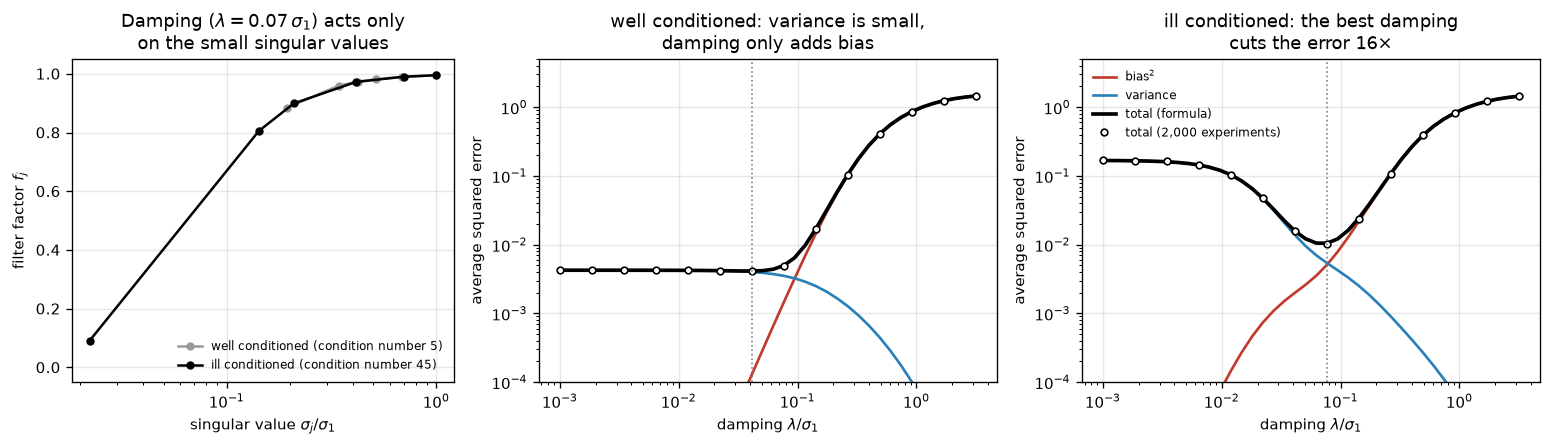

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), gridspec_kw=dict(width_ratios=[1, 1.2, 1.2]))
for name, col in (("well conditioned", "0.6"), ("ill conditioned", "k")):
    r = BV[name]
    axes[0].semilogx(r["S"], r["S"] ** 2 / (r["S"] ** 2 + 0.07 ** 2), "o-", ms=4, color=col,
                     label=f"{name} (condition number {r['cond']:.0f})")
axes[0].set(xlabel=r"singular value $\sigma_j/\sigma_1$", ylabel=r"filter factor $f_j$", ylim=(-0.05, 1.05),
            title=r"Damping ($\lambda=0.07\,\sigma_1$) acts only" + "\non the small singular values")
axes[0].legend(fontsize=7, frameon=False)
for ax, name in zip(axes[1:], ("well conditioned", "ill conditioned")):
    r = BV[name]
    ax.loglog(r["lam"], r["bias2"], color="#c0392b", lw=1.6, label=r"bias$^2$")
    ax.loglog(r["lam"], r["var"], color="#2980b9", lw=1.6, label="variance")
    ax.loglog(r["lam"], r["bias2"] + r["var"], color="k", lw=2.2, label="total (formula)")
    ax.loglog(r["lam"][::3], r["mc"][::3], "o", ms=4, mfc="white", mec="k", label="total (2,000 experiments)")
    k = int(np.argmin(r["bias2"] + r["var"]))
    ax.axvline(r["lam"][k], color="0.5", ls=":", lw=1)
    gain = (r["bias2"] + r["var"])[0] / (r["bias2"] + r["var"])[k]
    ax.set(xlabel=r"damping $\lambda/\sigma_1$", ylabel="average squared error", ylim=(1e-4, 5),
           title=(f"{name}: variance is small,\ndamping only adds bias" if gain < 1.5
                  else f"{name}: the best damping\ncuts the error {gain:.0f}×"))
axes[2].legend(fontsize=7, frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


Read the three panels from left to right.

The filter factors say *where* damping acts: on the smallest singular values, and hardly anywhere
else. With the well-spread rays of the real earthquake, no singular value is small, so there is
little variance to remove: the undamped answer is already the best, and every bit of damping only
adds bias. With the narrow cone, the smallest singular value is tiny, the variance is large, and
damping removes most of it at the cost of a little bias — the total error falls sharply before
the bias takes over. The open circles are 2,000 real repeated experiments; they sit on the
formula.

**Whether damping helps is a property of $G$, not of taste.** The same $\lambda$ that rescues one
geometry spoils another, and the bias–variance split says which case you are in. The tomography of
Session 5, *Tomography*, lives entirely in the second panel's world.

#### Optional: the L-curve

On real data there is no truth, so bias cannot be computed and the curves above cannot be drawn.
The classical substitute is the **L-curve**: plot the misfit $|d - G\hat m|$ against the model size
$|\hat m|$ as $\lambda$ varies. Small $\lambda$ gives a small misfit and a large model (the variance
side); large $\lambda$ a small model and a large misfit (the bias side); the curve has a corner
between them, and the corner is the usual choice. It is a heuristic for the minimum of the
black curve above, and it can be wrong; Session 1's cross-validation — choosing $\lambda$ by how well
the answer predicts data it was not fitted to — is the other route, and Part B returns to it.

**Exercise 2.** Damping towards zero says "the moment tensor should be small". That is not the only
prior a seismologist might hold. Suppose you believed instead that the source is close to some
reference mechanism $m_0$ — the one the catalogue published for a nearby earthquake, say. Write the
damped solution about $m_0$,
$$\hat m = m_0 + (G^\top G + \lambda^2 I)^{-1}G^\top (d - G m_0),$$
and print, over $\lambda$ from 0.01 to 30 with `m0 = mt_to_vec(sdr_to_mt(0, 45, 90))` — a mechanism
deliberately unlike the truth — the Kagan angle to the truth and to `m0`, and the misfit, on the
poorly conditioned geometry `G_n`. Watch which one the answer approaches, and what the misfit is
doing while it happens.


In [21]:
m0 = mt_to_vec(sdr_to_mt(0, 45, 90))
print(f"m0 is {kagan(vec_to_mt(m0), M_true):.0f}° from the truth\n")
print(f"{'lambda':>7} {'to the truth':>14} {'to m0':>8} {'misfit':>9}")
for lam in (0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0):
    m_ref = m0 + np.linalg.solve(G_n.T @ G_n + lam ** 2 * np.eye(6), G_n.T @ (d_n - G_n @ m0))
    print(f"{lam:7.2f} {kagan(vec_to_mt(m_ref), M_true):13.1f}° {kagan(vec_to_mt(m_ref), vec_to_mt(m0)):7.1f}°"
          f" {np.linalg.norm(d_n - G_n @ m_ref):9.4f}")


m0 is 98° from the truth

 lambda   to the truth    to m0    misfit
   0.01           7.5°   102.2°    0.3083
   0.10           9.9°   101.3°    0.3120
   0.30          25.2°    89.4°    0.3304
   1.00          54.7°    73.5°    0.6586
   3.00          73.8°    53.2°    2.7893
  10.00          91.8°    12.5°    6.9783
  30.00          97.6°     1.5°    8.4992


By $\lambda = 30$ the answer *is* `m0`, within two degrees of the mechanism we assumed and nearly a
right angle from the one that made the data. That much is obvious, and the misfit has risen
nearly thirty-fold to announce it.

The dangerous part is the top of the table. Between $\lambda = 0.1$ and $\lambda = 0.3$ the misfit
rises by about a tenth — a change no one would look at twice — while the answer moves 12° towards
`m0`. **A prior moves the answer before the misfit notices.** A prior is a claim about the world,
and if it is wrong the inversion will quietly hand it back to you. This is the bias of the section
above, made visible: damping about a wrong $m_0$ is pure bias towards $m_0$.


### A.6 · A constraint removes a column

Damping is a soft prior. A **constraint** is a hard one, and it is even simpler than it looks.

The trace of the moment tensor, $M_{xx} + M_{yy} + M_{zz}$, is its **isotropic** part: a source that
changes volume, like an explosion or a cavity collapsing. Slip on a plane has none, so a great deal
of routine practice inverts for a **deviatoric** tensor, forcing the trace to zero. That sounds like
a different method. It is one substitution:

$$M_{zz} = -(M_{xx} + M_{yy}).$$

Put that into $d = Gm$ and the third column disappears, its contribution folded into the first two.
Six unknowns become five, and the matrix gets better conditioned because the direction that was
hardest to determine — A.4 showed it was $M_{zz}$ — is no longer being determined at all.


In [22]:
def deviatoric(G):
    """Impose Mzz = -(Mxx + Myy): the third column's contribution folds into the first two."""
    return np.column_stack([G[:, 0] - G[:, 2], G[:, 1] - G[:, 2], G[:, 3], G[:, 4], G[:, 5]])


def restore_mzz(b5):
    """The six components again, after a five-column solve."""
    b5 = np.asarray(b5, float)
    return np.array([b5[0], b5[1], -(b5[0] + b5[1]), b5[2], b5[3], b5[4]])


In [23]:
# a source with a real isotropic part: a double couple plus 30 % volume increase
m_iso = m_true + 0.30 * mt_to_vec(np.eye(3))
d_iso = G @ m_iso + rng.normal(0, NOISE, len(AZ))
b6 = np.linalg.lstsq(G, d_iso, rcond=None)[0]
b5 = restore_mzz(np.linalg.lstsq(deviatoric(G), d_iso, rcond=None)[0])
print(f"condition number: six columns {np.linalg.cond(G):5.1f}   five columns {np.linalg.cond(deviatoric(G)):5.1f}")
print(f"\ntrue isotropic part      : {np.trace(vec_to_mt(m_iso)) / 3:+.3f}")
print(f"six-column solution      : {np.trace(vec_to_mt(b6)) / 3:+.3f}   "
      f"misfit {np.linalg.norm(d_iso - G @ b6):.4f}")
print(f"five-column (deviatoric) : {np.trace(vec_to_mt(b5)) / 3:+.3f}   "
      f"misfit {np.linalg.norm(d_iso - G @ b5):.4f}")
print(f"\nKagan angle to the truth: six columns {kagan(vec_to_mt(b6), M_true):.1f}°, "
      f"five columns {kagan(vec_to_mt(b5), M_true):.1f}°")

# and now the same comparison on a source that really has no isotropic part
d_dc = G @ m_true + rng.normal(0, NOISE, len(AZ))
c6 = np.linalg.lstsq(G, d_dc, rcond=None)[0]
c5 = restore_mzz(np.linalg.lstsq(deviatoric(G), d_dc, rcond=None)[0])
print("\nthe same two fits to a source that is pure slip on a plane:")
print(f"  six columns : misfit {np.linalg.norm(d_dc - G @ c6):.4f}   "
      f"isotropic part {np.trace(vec_to_mt(c6)) / 3:+.3f}   Kagan {kagan(vec_to_mt(c6), M_true):.1f}°")
print(f"  five columns: misfit {np.linalg.norm(d_dc - G @ c5):.4f}   "
      f"isotropic part {np.trace(vec_to_mt(c5)) / 3:+.3f}   Kagan {kagan(vec_to_mt(c5), M_true):.1f}°")


condition number: six columns   5.2   five columns   2.7

true isotropic part      : +0.300
six-column solution      : +0.277   misfit 0.3157
five-column (deviatoric) : +0.000   misfit 1.0039

Kagan angle to the truth: six columns 2.2°, five columns 16.0°

the same two fits to a source that is pure slip on a plane:
  six columns : misfit 0.3122   isotropic part +0.002   Kagan 0.7°
  five columns: misfit 0.3122   isotropic part +0.000   Kagan 0.7°


Read the two experiments together.

When the source **does** have an isotropic part, the constraint costs misfit — it cannot produce
the signal that is there — and it distorts the orientation as well, because the inversion tries to
explain an isotropic signal with the five components it is allowed.

When the source **does not**, the constraint costs almost no misfit and the unconstrained fit
reports a small isotropic part anyway, which is noise landing in the worst-resolved direction.

That is the honest test of a constraint, and it is the test Part B will run on a real earthquake:
**fit with the constraint and without it, and see what the extra freedom buys.** If it buys almost
nothing, the data did not need it, and the extra number in the answer is noise dressed as physics.


### A.7 · Two error bars, and the bigger one is not the obvious one

Session 1's error bar came from the noise: with independent Gaussian errors of standard deviation
$\sigma_d$,

$$\operatorname{Cov}(\hat m) = \sigma_d^2 (G^\top G)^{-1} ,$$

and everything in it is computable from $G$ and the residuals. That is the error bar an inversion
prints.

But $G$ is not measured. It is **assumed**. Every entry of it came from a take-off angle and an
azimuth that a location program produced from a velocity model that is itself approximate. If the
model is wrong, the rays leave at different angles than we think, and the rows of $G$ are wrong —
and no amount of care with the residuals will show it, because the residuals are computed against
the same wrong $G$.

So there are two experiments to run. Perturb the **data** and see how the answer moves. Then
perturb the **assumptions inside $G$** and see how the answer moves.


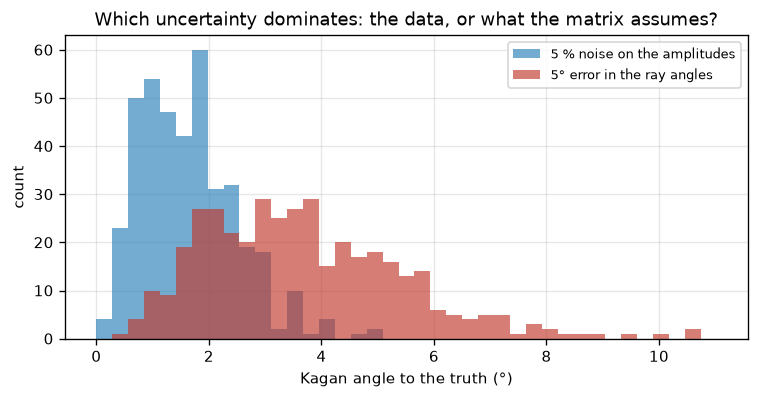

from 5 % amplitude noise : median  1.6°, 90th percentile  2.8°
from 5° angle error      : median  3.5°, 90th percentile  5.9°

the error bar the inversion would print, from the noise alone:
    Mxx ±0.026  Myy ±0.014  Mzz ±0.048  Mxy ±0.013  Mxz ±0.024  Myz ±0.019


In [24]:
NREP = 400
from_noise, from_angles = [], []
d_true = G @ m_true
for _ in range(NREP):
    m_n = np.linalg.lstsq(G, d_true + rng.normal(0, NOISE, len(AZ)), rcond=None)[0]
    from_noise.append(kagan(vec_to_mt(m_n), M_true))
    # the same data, but the take-off angles we believe are wrong by a few degrees
    G_p = ray_rows(AZ + rng.normal(0, 5, len(AZ)), IH + rng.normal(0, 5, len(IH)))
    m_p = np.linalg.lstsq(G_p, d_true, rcond=None)[0]
    from_angles.append(kagan(vec_to_mt(m_p), M_true))

fig, ax = plt.subplots(figsize=(6.4, 3.4))
bins = np.linspace(0, max(max(from_noise), max(from_angles)) * 1.05, 40)
ax.hist(from_noise, bins=bins, alpha=0.65, color="#2980b9", label="5 % noise on the amplitudes")
ax.hist(from_angles, bins=bins, alpha=0.65, color="#c0392b", label="5° error in the ray angles")
ax.set(xlabel="Kagan angle to the truth (°)", ylabel="count",
       title="Which uncertainty dominates: the data, or what the matrix assumes?")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"from 5 % amplitude noise : median {np.median(from_noise):4.1f}°, 90th percentile "
      f"{np.percentile(from_noise, 90):4.1f}°")
print(f"from 5° angle error      : median {np.median(from_angles):4.1f}°, 90th percentile "
      f"{np.percentile(from_angles, 90):4.1f}°")
cov = NOISE ** 2 * np.linalg.inv(G.T @ G)
print("\nthe error bar the inversion would print, from the noise alone:")
print("   ", "  ".join(f"{n} ±{np.sqrt(cov[j, j]):.3f}" for j, n in enumerate(labels)))


With these rays the error from a 5° mistake in the angles is more than twice the error from 5 %
amplitude noise — and the printed error bar knows only about the second. The lesson is not that
one number is always bigger. It is that **the printed error bar answers only the first
question**, and the second has to be asked separately, by perturbing the assumptions and
re-inverting — a Monte-Carlo uncertainty estimate. For first motions that is exactly what HASH
(Hardebeck & Shearer, 2002) added to FPFIT, and A.11 builds it.


## First motions: the same problem as classification

### A.8 · When the data are signs, many mechanisms fit

Everything so far assumed we measure the $P$ amplitude. In practice that is the harder measurement:
it needs the instrument response, a correction for how the wave spread and lost energy on the way,
and a clean record. What is almost always available instead is the **sign** — did the ground first
move up or down? An analyst reads that off the trace in a second, and the network archive has
millions of them. A first motion is

$$y \;=\; \operatorname{sign}\!\big(g(\gamma)^\top m\big) \in \{+1, -1\},$$

the sign of exactly the row A.1 built. In machine-learning terms that is a **linear classifier**:
a weight vector $m$, a feature vector $g(\gamma)$ for each example, and a label given by which side
of the plane $g^\top m = 0$ the example falls on. The features are not the ray direction $\gamma$
itself but its six products $g(\gamma)$ — a **feature map**. In the three dimensions of $\gamma$
the boundary between up and down is curved (the two nodal planes, drawn as arcs on the focal
sphere); in the six dimensions of $g$ it is flat. Making a curved boundary flat by mapping the data
into more dimensions is the idea behind **kernel methods**; here the physics hands us the map.

One cost is immediate. $\operatorname{sign}(g^\top(cm)) = \operatorname{sign}(g^\top m)$ for any
$c > 0$: **first motions cannot determine the size of an earthquake**, only the direction of $m$.
That is why magnitudes come from amplitudes and mechanisms can come from signs.


In [25]:
polarity = np.sign(G @ m_true)
print(f"{len(polarity)} first motions: {(polarity > 0).sum()} up, {(polarity < 0).sum()} down")
for c in (0.01, 1.0, 100.0):
    print(f"  scaling the moment tensor by {c:6.2f} changes "
          f"{int((np.sign(G @ (c * m_true)) != polarity).sum())} of the {len(polarity)} polarities")


41 first motions: 33 up, 8 down
  scaling the moment tensor by   0.01 changes 0 of the 41 polarities
  scaling the moment tensor by   1.00 changes 0 of the 41 polarities
  scaling the moment tensor by 100.00 changes 0 of the 41 polarities


With amplitudes we solved for $m$ directly. With signs there is nothing to solve: we **search**.
Lay out a grid over strike, dip and rake, each grid point a double couple of unit size. For each
one, compute the P amplitude it sends to every station, $A = g(\gamma)^\top m$: A.1's radiation
$R(\gamma)$. For a double couple of unit size $A$ lies between $-1$ and $+1$, and it is $0$ for a ray
on a nodal plane.

A mechanism **explains** a reading $y$ ($+1$ for up, $-1$ for down) when $A$ has the same sign. The
product $yA$ says how safely:

- its **sign** says whether the reading is explained: $yA > 0$ when the predicted and observed first
  motions agree, $yA < 0$ when they disagree;
- its **size** says how far the prediction is from flipping. $yA = 0.9$ means the mechanism predicts
  a strong swing in the direction that was read, and turning the mechanism a little will not
  change that. $yA = 0.05$ means the ray passes just beside a nodal plane, and a slight turn would
  put it on the other side.

In machine learning, the label times the classifier's score, here $yA$, is called the **margin** of
that example: positive when it is classified correctly, and larger the more safely it is.


In [26]:
def dc_grid(step_strike, step_dip, step_rake):
    """Every double couple on a strike/dip/rake grid, each of unit size, so that |g @ m| <= 1."""
    s, d, r = [a.ravel() for a in np.meshgrid(np.arange(0, 360, step_strike), np.arange(step_dip, 90.1, step_dip),
                                              np.arange(-180, 180, step_rake), indexing="ij")]
    V = np.array([mt_to_vec(sdr_to_mt(*x)) for x in zip(s, d, r)])
    return np.stack([s, d, r], 1), V


SDR3, V3 = dc_grid(3.0, 3.0, 3.0)
A3 = (G @ V3.T).astype(np.float32)                      # rays x mechanisms: the radiation A of A.1
fits = np.flatnonzero((np.sign(A3) == polarity[:, None]).all(0))
print(f"{len(V3):,} trial double couples on a 3-degree grid; {len(fits):,} explain every one of the "
      f"{len(polarity)} noise-free readings")
sub = fits[:: max(1, len(fits) // 300)]
spread = np.array([kagan(sdr_to_mt(*SDR3[k]), M_true) for k in sub])
print(f"how far they lie from the truth: median {np.median(spread):.1f}°, largest {spread.max():.1f}°")


432,000 trial double couples on a 3-degree grid; 163 explain every one of the 41 noise-free readings
how far they lie from the truth: median 13.1°, largest 25.9°


There are no reading errors here. Not one polarity is wrong. And still more than a hundred
mechanisms, spread over tens of degrees, explain every one of them. This is A.3's null space arriving by a
different road: there, two models could not be separated because their difference produced no
signal; here, because it produced a signal **too small to change any sign**. In machine learning
the set of models consistent with every training label is the **version space**; a sign is a
coarse measurement, and it leaves a set rather than an answer.

#### Which member of the set to report

Three natural answers, and each is a machine-learning idea.

1. **Any of them** — whichever the search lands on. With no reason to prefer one, it is arbitrary.
2. **The one with the widest margin**: the mechanism whose nodal planes stay farthest from every
   ray, i.e. that maximises the smallest $yA$. This is the idea of the **support vector machine
   (SVM)**: among all separating boundaries, choose the one with the most room on both sides,
   because a boundary that grazes a data point is fragile. FPFIT breaks ties this way (A.10).
3. **The average of the set**: average the unit tensors of all the members and take the member
   nearest that average. This is **ensemble averaging** — the idea behind bagging — and it is
   what HASH reports (A.11): the arbitrary part of each member cancels, the shared part stays.

There is a fourth way to get a margin: fit a standard linear SVM to the moment-tensor components
freely, which is quick, and snap the answer to the nearest double couple afterwards. We leave out
the isotropic part, which slip on a fault does not have: since $\gamma^\top I\gamma = 1$ for every
ray, it would add the same number to every station's score, an **intercept** hidden among the six.
Try all four on 400 planted mechanisms, still with perfect readings.


In [27]:
from sklearn.svm import SVC


def nearest_dc(m):
    """The double couple nearest a general tensor: keep its T and P axes (the eigenvectors of
    largest and smallest eigenvalue, the directions of greatest tension and compression)."""
    w, v = np.linalg.eigh(vec_to_mt(m))
    return np.outer(v[:, 2], v[:, 2]) - np.outer(v[:, 0], v[:, 0])


# `m` lists each off-diagonal component once, but the tensor holds it twice. Scaling those three
# entries by sqrt(2) makes dot products of the six numbers equal to the tensor's own inner product,
# sum_pq M_pq N_pq, so that no orientation of the axes is favoured.
FROB = np.array([1, 1, 1, np.sqrt(2), np.sqrt(2), np.sqrt(2)])
ISO = np.array([1.0, 1, 1, 0, 0, 0]) / np.sqrt(3)            # the isotropic direction, in scaled units
G_frob = G / FROB                                             # rows of unit length: g . m = G_frob . (m * FROB)
G_dev = G_frob - np.outer(G_frob @ ISO, ISO)                  # the same features with the isotropic part removed


picks, example = [], None
for t in range(400):
    truth = (rng.uniform(0, 360), np.degrees(np.arccos(rng.uniform(0, 1))), rng.uniform(-180, 180))
    Mt = sdr_to_mt(*truth)
    y = np.sign(G @ mt_to_vec(Mt))
    ok = np.flatnonzero((np.sign(A3) == y[:, None]).all(0))
    if len(ok) < 2:
        continue
    margin = (A3[:, ok] * y[:, None]).min(0)
    choice = dict(arbitrary=ok[rng.integers(len(ok))], margin=ok[np.argmax(margin)],
                  average=ok[np.argmax((V3[ok] * FROB) @ (V3[ok] * FROB).mean(0))])
    row = {k: kagan(sdr_to_mt(*SDR3[j]), Mt) for k, j in choice.items()}
    # a hard-margin linear SVM through the origin: a very large C allows no reading on the wrong side,
    # and adding each reading's mirror image (-g, -y) keeps the fitted intercept at exactly zero
    w = SVC(kernel="linear", C=1e8).fit(np.vstack([G_dev, -G_dev]), np.r_[y, -y]).coef_[0]
    row["svm"] = kagan(nearest_dc(w / FROB), Mt)
    picks.append(row)
    if example is None and row["average"] < row["margin"] < row["arbitrary"] and 100 < len(ok) < 400:
        example = dict(truth=truth, y=y, members=ok[:: max(1, len(ok) // 120)], n=len(ok), choice=choice)
picks = pd.DataFrame(picks)
names = dict(average="set average (HASH)", margin="widest margin (FPFIT's tie-break)",
             arbitrary="arbitrary member", svm="SVM, then nearest double couple")
for k, v in names.items():
    print(f"{v:46s} median {picks[k].median():4.1f}°   90th percentile {picks[k].quantile(0.9):4.1f}°")
print(f"({len(picks)} planted mechanisms)")


set average (HASH)                             median  5.5°   90th percentile 12.9°
widest margin (FPFIT's tie-break)              median  5.7°   90th percentile 14.0°
arbitrary member                               median  7.1°   90th percentile 17.8°
SVM, then nearest double couple                median  7.4°   90th percentile 18.9°
(381 planted mechanisms)


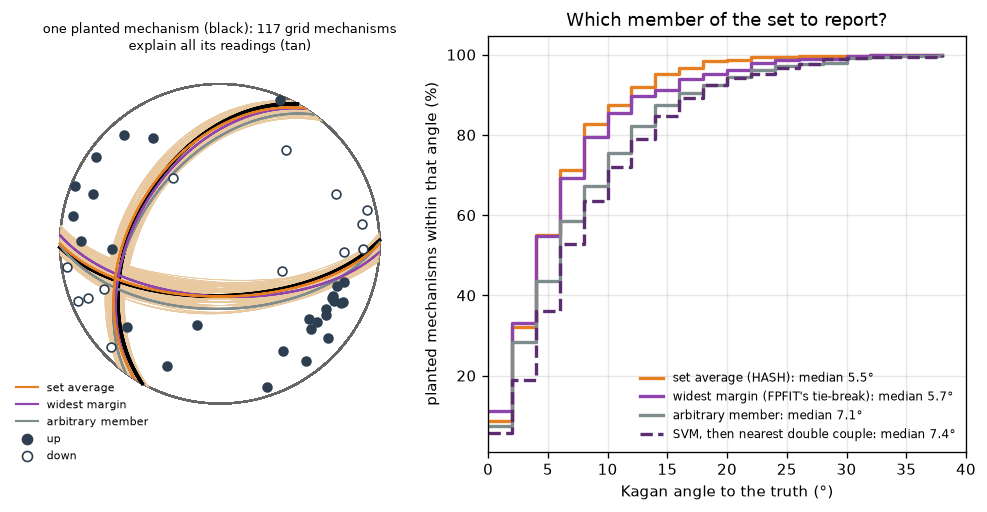

In [28]:
x_ray, y_ray = focal_xy(AZ, IH)
COLS = dict(arbitrary="#7f8c8d", margin="#8e44ad", average="#e67e22", svm="#5b2c6f")
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), gridspec_kw=dict(width_ratios=[1, 1.3]))
ax = axes[0]
for k in example["members"]:
    focal_sphere(ax, sdr_to_mt(*SDR3[k]), color="#e8c9a0", lw=0.4)
focal_sphere(ax, sdr_to_mt(*example["truth"]), color="k", lw=2.2)
for k in ("arbitrary", "margin", "average"):
    focal_sphere(ax, sdr_to_mt(*SDR3[example["choice"][k]]), color=COLS[k], lw=1.3)
yy = example["y"]
ax.scatter(x_ray[yy > 0], y_ray[yy > 0], s=28, c="#2c3e50", zorder=3)
ax.scatter(x_ray[yy < 0], y_ray[yy < 0], s=28, facecolors="white", edgecolors="#2c3e50", zorder=3)
ax.set_title(f"one planted mechanism (black): {example['n']} grid mechanisms\nexplain all its readings (tan)",
             fontsize=8)
ax.legend(handles=[plt.Line2D([], [], color=COLS[k], lw=1.3, label=lab) for k, lab in
                   (("average", "set average"), ("margin", "widest margin"), ("arbitrary", "arbitrary member"))]
          + [plt.Line2D([], [], ls="", marker="o", color="#2c3e50", label="up"),
             plt.Line2D([], [], ls="", marker="o", mfc="white", color="#2c3e50", label="down")],
          fontsize=6.5, frameon=False, loc="lower left", bbox_to_anchor=(-0.08, -0.12))
ax = axes[1]
bins = np.arange(0, 41, 2)
for k, lab in names.items():
    v = picks[k].values
    h, _ = np.histogram(np.clip(v, 0, 39.9), bins)
    ax.step(bins[:-1], np.cumsum(h) / len(v) * 100, where="post", lw=2, color=COLS[k], ls="--" if k.startswith("svm") else "-",
            label=f"{lab}: median {np.median(v):.1f}°")
ax.set(xlabel="Kagan angle to the truth (°)", ylabel="planted mechanisms within that angle (%)", xlim=(0, 40),
       title="Which member of the set to report?")
ax.legend(fontsize=7, frameon=False, loc="lower right")
plt.show()


**Averaging the set and taking the widest margin are about equally good, and both beat an
arbitrary member** — typically (the median) and more so in the bad cases (the 90th percentile).
Both use every reading rather than whichever member the search happened to hit: the average
cancels the arbitrary part of each member, and the widest margin stays as far as it can from every
ray.

**The SVM does worst.** It maximises its margin over *all* trace-free tensors, most of which are
not slip on a fault, and snapping the answer to a double couple afterwards throws that optimum
away. The widest-margin double couple is
the same idea searched over the right set. **Search the hypothesis space you believe in, not a
bigger one you project from.** From here on every method searches the same grid of double
couples.


### A.9 · A loss is a claim about the noise

Real readings are wrong sometimes. A search then needs a **loss**: a number that says how bad a
trial mechanism is, summed over readings. Write $z = yA$ for a reading's margin under the trial
mechanism. Four losses, all used in practice:

| loss | per reading | who uses it | what it claims |
|---|---|---|---|
| 0–1 | 1 if $z<0$, else 0 | counting wrong readings | every wrong reading is equally wrong |
| FPFIT | $w\,\sqrt{\lvert A\rvert}$ if $z<0$, else 0 (normalised) | the network's catalogue since 1985 | a reading near a nodal plane is expected to be wrong; a bad-quality one too |
| hinge | $\max(0,\ 1-\kappa z)$ | the SVM | wrong readings cost in proportion to how wrong; correct ones cost until they have a margin |
| logistic | $\log(1+e^{-\kappa z})$ | logistic regression | $P(\text{reading is right}) = 1/(1+e^{-\kappa z})$ |

In the last two, $\kappa > 0$ is a **sharpness**: it multiplies the margin before the loss sees it,
so a large $\kappa$ makes the loss nearly a step at $z = 0$ and a small one makes it nearly a
straight line. It is a knob, like the damping $\lambda$ of A.5, and choosing it is a regularisation
problem.

The first two are what seismology built; the last two are what machine learning built. Seen side
by side they differ in two ways: whether a reading on the right side still costs something (it
does for hinge and logistic, which is what rewards a margin), and whether the loss is **convex** in
$m$ — a bowl with one bottom, which gradient methods can slide down. Only hinge and logistic are;
the 0–1 and FPFIT losses are flat almost everywhere and jump at the boundary, which is why FPFIT
has to search a grid.


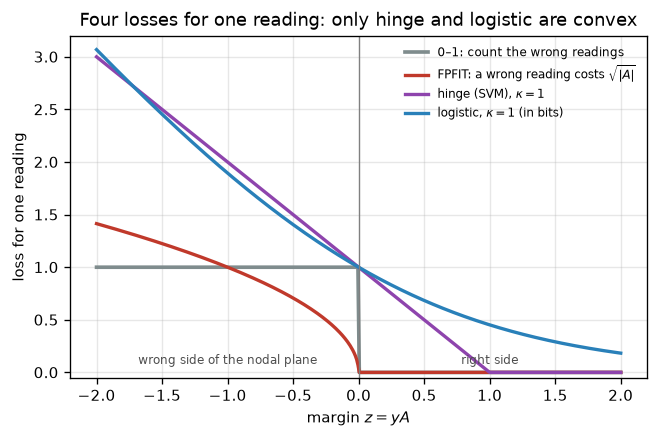

In [29]:
z = np.linspace(-2, 2, 400)
fig, ax = plt.subplots(figsize=(6.2, 3.7))
ax.plot(z, (z < 0).astype(float), color="#7f8c8d", lw=2.2, label="0–1: count the wrong readings")
ax.plot(z, np.where(z < 0, np.sqrt(np.abs(z)), 0), color="#c0392b", lw=2, label=r"FPFIT: a wrong reading costs $\sqrt{|A|}$")
ax.plot(z, np.maximum(0, 1 - z), color="#8e44ad", lw=2, label=r"hinge (SVM), $\kappa = 1$")
ax.plot(z, np.log2(1 + np.exp(-z)), color="#2980b9", lw=2, label=r"logistic, $\kappa = 1$ (in bits)")
ax.axvline(0, color="0.5", lw=0.8)
ax.text(-1.0, 0.08, "wrong side of the nodal plane", fontsize=7, color="0.3", ha="center")
ax.text(1.0, 0.08, "right side", fontsize=7, color="0.3", ha="center")
ax.set(xlabel=r"margin $z = yA$", ylabel="loss for one reading", ylim=(-0.05, 3.2),
       title="Four losses for one reading: only hinge and logistic are convex")
ax.legend(fontsize=7, frameon=False, loc="upper right")
plt.show()


Which loss is right depends on how the readings actually fail, and that is a question about data,
not about the loss. Part B measures how the Geysers readings go wrong and tests FPFIT's weights on a
twin of one earthquake. Here we take the loss the network uses and build it.


### A.10 · FPFIT, in a few lines

FPFIT (Reasenberg & Oppenheimer 1985) is the program behind the Northern California catalogue.
Its misfit for a trial mechanism is

$$F \;=\; \frac{\sum_k w_k \sqrt{|A_k|}\,[\,y_k \ne \operatorname{sign} A_k\,]}{\sum_k w_k\sqrt{|A_k|}} ,$$

a weighted fraction of wrong readings. Two weights, two claims about the noise:

- $\sqrt{|A_k|}$, recomputed for every trial: a reading the trial puts near its own nodal plane
  counts for little, because the trial itself predicts that reading is unreliable;
- $w_k$ from the pick quality through an assumed **error rate** $r$ for that quality:
  $w = 1/\sqrt{r(1-r)} - 2$ — zero for a coin flip ($r = 0.5$), large for a reliable class. The
  Northern California network assumes $r$ = 0.023 for its best picks and 0.23 for its third class.

Ties go to the mechanism with the largest denominator: the one whose planes stay farthest from the
readings — A.8's widest margin. The full program, `gm.fpfit`, saves time with a coarse search
first and a fine one around the best coarse regions; the cell below searches one fine grid
everywhere.


In [30]:
SDR5, V5 = dc_grid(5.0, 5.0, 10.0)                 # FPFIT's fine grid: 5, 5 and 10 degrees


def fpfit_simple(azimuth, takeoff, y, quality, V=V5):
    """FPFIT's misfit on one grid, with its tie-break. `quality` is the pick class (0 best ... 3)."""
    g = ray_rows(azimuth, takeoff)
    A = g @ V.T                                                          # readings x trials
    w = gm.obs_weight(quality)[:, None] * np.sqrt(np.abs(A))
    F = (w * (np.sign(A) != y[:, None])).sum(0) / w.sum(0)
    tie = np.flatnonzero(F <= F.min() + 1e-9)
    return tie[np.argmax(w.sum(0)[tie])]                                 # widest margin among the best


### A.11 · HASH: an error bar that includes the errors in G

A.7 showed that the error that matters most is often not in the data but in $G$ — here, in the
take-off angles, which come from a velocity model that is certainly wrong by a few degrees. FPFIT's
uncertainty ignores that: it is computed from the readings alone. **HASH** (Hardebeck & Shearer
2002) adds three steps, each a machine-learning idea:

1. **Perturb the inputs.** Draw 30 versions of every take-off angle and azimuth from their
   uncertainty (a few degrees) — **data augmentation**, applied to the features.
2. **Keep everything that fits well enough.** For each version, keep every mechanism whose number
   of wrong readings is within a tolerance of the best — the tolerance is a guess at how many
   readings are bad (10 %) — and pool the kept sets. This is the version space of A.8 with room
   for label noise.
3. **Report the centre, and how concentrated the set is.** Average the pooled set, dropping the
   member farthest from the average until all are within 45°; the fraction left is the
   **probability**, and its spread and fit give a quality grade A–D. This is an **ensemble** and
   its **agreement**, used as a confidence.

HASH's grid is not strike/dip/rake but a set of rotations spread evenly over orientation, and a
mechanism is a pair of vectors: the fault normal and the slip. A ray is compressional when it lies
on the same side of both planes, so the prediction for every trial is the sign of a product of two
dot products — no moment tensor needed.


In [31]:
HASH_GRID = gm.hash_grid(5.0)                      # (slip, normal) of 31,032 trial mechanisms


def hash_simple(azimuth_mc, takeoff_mc, y, bad=0.1, seed=0):
    """HASH's acceptable set, pooled over trial versions of the ray angles, and its preferred
    mechanism. Column t of `azimuth_mc`/`takeoff_mc` is trial t (column 0 the angles as given)."""
    slip, normal = HASH_GRID
    n_bad = max(int(np.floor(len(y) * bad + 0.5)), 2)                      # tolerated wrong readings
    extra = max(int(np.floor(len(y) * bad / 2 + 0.5)), 2)                  # (rounded as HASH rounds)
    keep = np.zeros(len(slip), bool)
    for t in range(azimuth_mc.shape[1]):
        ray = gm.to_car(180 - takeoff_mc[:, t], azimuth_mc[:, t])          # HASH measures from up
        wrong = (np.sign((ray @ slip.T) * (ray @ normal.T)) != y[:, None]).sum(0)
        keep |= wrong <= max(n_bad, wrong.min() + extra)
    use = np.flatnonzero(keep)
    if len(use) > 500:                                                     # as HASH: at most 500 into the average
        use = np.random.default_rng(seed).choice(use, 500, replace=False)
    best = gm.mech_prob(normal[use], slip[use], cangle=45.0)[0]            # average, trim, probability
    return best, keep


def angle_trials(azimuth, takeoff, n=30, sigma=5.0):
    """n versions of the ray angles: the given ones, and n-1 perturbed by sigma degrees."""
    return (np.column_stack([azimuth] + [azimuth + rng.normal(0, sigma, len(azimuth)) for _ in range(n - 1)]),
            np.column_stack([takeoff] + [takeoff + rng.normal(0, sigma, len(takeoff)) for _ in range(n - 1)]))


y = np.sign(G @ m_true) * np.where(rng.random(len(AZ)) < 0.1, -1, 1)
az_mc, ih_mc = angle_trials(AZ, IH)
best, keep = hash_simple(az_mc, ih_mc, y)
print(f"the cell: {keep.sum():,} mechanisms kept, preferred {tuple(round(v) for v in best['sdr'])}, "
      f"probability {best['prob']:.2f}, {kagan(sdr_to_mt(*best['sdr']), M_true):.1f}° from the truth")
slip, normal = HASH_GRID
kept = np.flatnonzero(keep)
nearest = min(kagan(sdr_to_mt(*gm.fpcoor(normal[k], slip[k])), M_true) for k in kept)
print(f"the kept set is {keep.mean():.1%} of the grid; its member nearest the truth is {nearest:.1f}° from it")


the cell: 1,288 mechanisms kept, preferred (342, 70, -160), probability 0.51, 15.0° from the truth
the kept set is 4.2% of the grid; its member nearest the truth is 2.0° from it


What HASH adds to FPFIT is the set, and here it does what an error bar should: it holds a few per cent of all
possible mechanisms, and the truth lies inside it, within the grid's 5° spacing of a member. The
set says how many mechanisms survive once the angles are allowed to be wrong, and how
tightly they cluster — here the probability says 60 % of the pooled set lies within 45° of the
preferred mechanism, which earns a middling grade even with 41 readings and one wrong in ten. Whether
that set contains the truth, when the readings and the angles are wrong in the ways real ones are,
can only be tested on many planted mechanisms — Part B does it on a twin of the Mw 5.0.


#### Adding S/P amplitude ratios

The second version of HASH (Hardebeck & Shearer, 2003, *BSSA* 93, 2434–2444,
[10.1785/0120020236](https://doi.org/10.1785/0120020236)) uses one more kind of data at each station
where the S wave is recorded too: the ratio of the S amplitude to the P amplitude.

**Where the S amplitude comes from.** The same theory that gives A.1's P radiation,
$P = \gamma^\top M\gamma$, gives the S radiation too (Aki & Richards, 2002, eq. 4.29). Take the vector
$M\gamma$. Its part along the ray has size $P$; its part at right angles to the ray, $M\gamma - P\,\gamma$,
is what drives the S wave — a push sideways to the ray shears the rock — and its length is the S
radiation. The two parts are at right angles, so by Pythagoras

$$S^2 \;=\; |M\gamma|^2 - P^2 .$$

For slip on a fault, $M = \mathbf n\,\mathbf s^\top + \mathbf s\,\mathbf n^\top$ (A.1, step 4, with
$M_0 = 1$), so $M\gamma = \mathbf n\,(\gamma\cdot\mathbf s) + \mathbf s\,(\gamma\cdot\mathbf n)$. Because $\mathbf n$
and $\mathbf s$ are unit vectors at right angles, $|M\gamma|^2 = (\gamma\cdot\mathbf n)^2 + (\gamma\cdot\mathbf s)^2$,
and

$$P = 2\,(\gamma\cdot\mathbf n)(\gamma\cdot\mathbf s), \qquad
S = \sqrt{(\gamma\cdot\mathbf n)^2 + (\gamma\cdot\mathbf s)^2 - P^2} .$$

A check: for a ray in the fault plane, $\gamma\cdot\mathbf n = 0$, the vector $M\gamma = \mathbf n\,(\gamma\cdot\mathbf s)$
is straight across the ray. There $P = 0$, and all of it goes into S.

One more factor turns radiation into amplitude. The exact formula at the end of A.1 divides by the
cube of the wave speed, and S travels slower than P, at $\beta$ instead of $\alpha$; so for the same
radiation the S wave is $(\alpha/\beta)^3 \approx 4.9$ times larger in crustal rock. The predicted
ratio is $4.9\,S/|P|$.

**Why a ratio helps.** It does not depend on the size of the earthquake, and hardly on the path,
because P and S travel nearly the same one. And it is most informative exactly where first motions
are least: near a nodal plane $P$ is tiny and its sign unreliable, but the ratio is large and well
defined.

**How HASH combines the two.** The two kinds of data pose two different tasks. A polarity is a
**label**, $+1$ or $-1$: classification, scored by counting the wrong ones (A.9's 0–1 loss). A ratio
is a **continuous number**: regression, scored by the sum of the absolute differences between
observed and predicted $\log_{10}$ ratios (an L1 loss, which shrugs off an occasional bad ratio). The
two scores are in different units — a count of readings against a sum of logarithms — so they
cannot simply be added. The usual machine-learning answer is to add them anyway with a weight, or,
in a probabilistic method, to turn each into a log-likelihood with its own noise model; either way
the weight between the two tasks has to be chosen. HASH avoids that choice. It gives each score its
own tolerance, set by the noise expected in that kind of data:

- **polarities**: at most 10 % of them wrong, or the best mechanism's count plus a little (A.11);
- **ratios**: an average misfit of at most 0.3 per ratio, or the best mechanism's misfit plus half
  that. The misfit is measured in $\log_{10}$ units, and $\log_{10} 2 \approx 0.3$, so 0.3 is the misfit
  of a ratio measured twice as large as predicted, or half as large — the scatter Hardebeck &
  Shearer (2003) found in real S/P ratios;

and keeps a mechanism only if it passes **both**. The acceptable set is the mechanisms consistent
with the polarities *and* consistent with the ratios: the intersection of two version spaces, one
per task. If no mechanism passes both, HASH loosens the ratio tolerance and keeps the polarity one,
trusting the labels over the noisier numbers.


In [32]:
def log_sp(ray, normal, slip):
    """Predicted log10 S/P for every ray (rows) and grid mechanism (columns), (alpha/beta)^3 = 4.9."""
    gn, gs = ray @ normal.T, ray @ slip.T
    P = 2 * gn * gs
    S = np.sqrt(np.clip(gn ** 2 + gs ** 2 - P ** 2, 0, None))
    return np.log10(4.9 * S / np.maximum(np.abs(P), 1e-4))


def hash_sp(azimuth_mc, takeoff_mc, y, sp, bad=0.1, sp_noise=0.3, seed=0):
    """hash_simple with S/P ratios: a mechanism is kept in a trial only if it passes BOTH tests."""
    slip, normal = HASH_GRID
    n_bad, extra = max(int(np.floor(len(y) * bad + 0.5)), 2), max(int(np.floor(len(y) * bad / 2 + 0.5)), 2)
    q_bad, q_extra = max(len(sp) * sp_noise, 2.0), max(len(sp) * sp_noise / 2, 2.0)
    keep = np.zeros(len(slip), bool)
    for t in range(azimuth_mc.shape[1]):
        ray = gm.to_car(180 - takeoff_mc[:, t], azimuth_mc[:, t])
        wrong = (np.sign((ray @ slip.T) * (ray @ normal.T)) != y[:, None]).sum(0)
        q = np.abs(log_sp(ray, normal, slip) - sp[:, None]).sum(0)           # L1 misfit of the ratios
        ok_pol = wrong <= max(n_bad, wrong.min() + extra)
        keep |= ok_pol & (q <= max(q_bad, q[ok_pol].min() + q_extra))
    use = np.flatnonzero(keep)
    if len(use) > 500:
        use = np.random.default_rng(seed).choice(use, 500, replace=False)
    return gm.mech_prob(normal[use], slip[use], cangle=45.0)[0], keep


# A dense network (all 41 rays) and a sparse one (12 of them), 100 planted mechanisms, 10 % of the
# polarities wrong, S/P ratios at every station with random errors of 0.3 in log10 (a factor of 2),
# and 5-degree ray errors.
sparse = np.sort(rng.choice(len(AZ), 12, replace=False))
rows = []
for t in range(100):
    truth = (rng.uniform(0, 360), np.degrees(np.arccos(rng.uniform(0, 1))), rng.uniform(-180, 180))
    Mt = sdr_to_mt(*truth)
    for net, idx in (("dense, 41 stations", np.arange(len(AZ))), ("sparse, 12 stations", sparse)):
        az, ih = AZ[idx], IH[idx]
        g = ray_rows(az, ih)
        y = np.sign(g @ mt_to_vec(Mt)) * np.where(rng.random(len(idx)) < 0.1, -1, 1)
        ray = gm.to_car(180 - ih, az)
        A = g @ mt_to_vec(Mt)                                            # P radiation, A.1
        Svec = ray @ Mt - A[:, None] * ray                               # the motion across the ray
        sp_obs = np.log10(4.9 * np.linalg.norm(Svec, axis=1) / np.maximum(np.abs(A), 1e-4)) \
            + rng.normal(0, 0.3, len(idx))
        az_mc, ih_mc = angle_trials(az, ih)
        for data, (best, keep) in (("polarities", hash_simple(az_mc, ih_mc, y)),
                                   ("polarities + S/P", hash_sp(az_mc, ih_mc, y, sp_obs))):
            rows.append(dict(network=net, data=data, error=kagan(sdr_to_mt(*best["sdr"]), Mt),
                             kept=keep.mean()))
SP = pd.DataFrame(rows).groupby(["network", "data"]).agg(median_error=("error", "median"),
                                                          p90_error=("error", lambda v: v.quantile(0.9)),
                                                          set_size=("kept", "median"))
print("Kagan angle to the truth, and the share of the grid HASH keeps (medians over 100 mechanisms):\n")
for (net, data), r in SP.iterrows():
    print(f"{net:21s} {data:18s}  error median {r.median_error:4.1f}°, 90th percentile {r.p90_error:4.1f}°;"
          f"  set {100 * r.set_size:4.1f} % of the grid")


Kagan angle to the truth, and the share of the grid HASH keeps (medians over 100 mechanisms):

dense, 41 stations    polarities          error median 16.5°, 90th percentile 39.6°;  set  3.4 % of the grid
dense, 41 stations    polarities + S/P    error median  9.1°, 90th percentile 16.2°;  set  1.5 % of the grid
sparse, 12 stations   polarities          error median 37.5°, 90th percentile 67.8°;  set 24.9 % of the grid
sparse, 12 stations   polarities + S/P    error median 16.6°, 90th percentile 38.2°;  set  4.6 % of the grid


**The ratios help, and they help most where polarities are weakest.** With 12 stations the
polarities leave a quarter of all mechanisms acceptable and a typical answer tens of degrees off;
adding a ratio at each station shrinks the set several-fold and more than halves the error. With 41
stations the gain is smaller in degrees, as Hardebeck & Shearer (2003) found on real aftershocks:
ratios improve poorly constrained mechanisms most. They did so here even though a typical ratio
was measured wrong by a factor of 2, because they carry information of a different kind.

The two kinds also cover each other's blind spot. A ratio has no sign: a mechanism and its opposite,
$-M$, with the compressional and dilatational quadrants swapped, predict exactly the same ratios
everywhere, so ratios alone cannot tell them apart. A first motion is only a sign, and says nothing
about how large the pulse is. **A classification label and a regression target, each informative
where the other is not** — which is why HASH keeps a mechanism only when it passes both tests.


#### Optional: the probabilistic route, and machine-learned polarities

Logistic regression turned a mechanism into a probability for every reading. Take that seriously
and the whole inversion becomes Bayesian: a prior over mechanisms, the logistic likelihood of the
readings, and a posterior whose spread is the error bar. **MTfit** (Pugh & White 2018) does this for
polarities and amplitude ratios together. The other frontier is upstream: networks now read the
polarity itself with a neural network (Uchide 2020; Kuang, Li & Zhang 2021; DiTingMotion, Zhao et
al. 2023), and hand the result to the same 1985-style search. A picker that
outputs a calibrated probability is exactly the input a logistic likelihood wants — which is where
Session 8, *Phase picking*, picks this up.


## Waveforms: regression again, and an Earth model that is wrong

### A.12 · A seismogram is also $d = Gm$

A.1 used the $P$ amplitude at one instant. A whole seismogram works the same way and for the same
reason: the equations of motion are linear, so the ground displacement at a station is a sum of
the six moment-tensor components, each multiplying a **waveform** rather than a number,

$$u(t) \;=\; \sum_{k=1}^{6} m_k\, g_k(t) .$$

The $g_k(t)$ are **Green's functions**: the seismogram a unit $M_{xx}$, a unit $M_{yy}$ and so on
would each produce at that station, through the Earth between them. The design matrix now has one
row per *sample*, and its columns are seismograms. For a layered Earth the six columns at any
azimuth are built from ten **fundamental** Green's functions — computed once per distance and
depth, here with Saikia's (1994) frequency–wavenumber program for **gil7**, the northern California model
Berkeley's moment tensors use — times sines and cosines of the azimuth. The cell below is that
construction, the one TDMT (Dreger, 2003) uses for Berkeley's published tensors. Fitting it by least
squares **is TDMT**, the time-domain moment-tensor inversion.

Everything from A.2 to A.7 carries over. What is new is that $G$ now depends on the whole velocity
model, and the velocity model is certainly wrong. A.7 showed that errors in $G$ can matter more than
noise; here they arrive as **timing**: in a slower Earth every wave arrives late, and not by the
same amount.


In [33]:
from geysers_data import green_functions, true_earth_green, mw5_waveforms

KEYS = ("TSS", "TDS", "RSS", "RDS", "RDD", "ZSS", "ZDS", "ZDD", "REX", "ZEX")


def mt_design(gf, azimuth):
    """Per-component design matrices {T, R, Z}: samples x 6, columns [Mxx Myy Mxy Mxz Myz Mzz].
    Each entry is a fundamental Green's function times a function of the azimuth."""
    a = np.radians(azimuth)
    s1, c1, s2, c2 = np.sin(a), np.cos(a), np.sin(2 * a), np.cos(2 * a)
    g = {k: np.asarray(gf[k], float) for k in KEYS}
    zero = np.zeros_like(g["TSS"])
    T = np.stack([0.5 * s2 * g["TSS"], -0.5 * s2 * g["TSS"], -c2 * g["TSS"],
                  -s1 * g["TDS"], c1 * g["TDS"], zero], axis=1)
    R = np.stack([g["RDD"] / 6 - 0.5 * c2 * g["RSS"] + g["REX"] / 3,
                  g["RDD"] / 6 + 0.5 * c2 * g["RSS"] + g["REX"] / 3,
                  -s2 * g["RSS"], c1 * g["RDS"], s1 * g["RDS"], g["REX"] / 3 - g["RDD"] / 3], axis=1)
    Zc = np.stack([g["ZDD"] / 6 - 0.5 * c2 * g["ZSS"] + g["ZEX"] / 3,
                   g["ZDD"] / 6 + 0.5 * c2 * g["ZSS"] + g["ZEX"] / 3,
                   -s2 * g["ZSS"], c1 * g["ZDS"], s1 * g["ZDS"], g["ZEX"] / 3 - g["ZDD"] / 3], axis=1)
    return {"T": T, "R": R, "Z": Zc}


def design_vector(M):
    """A north-east-down tensor in the design's order and convention (the Green's functions are
    for 1e20 dyne-cm and a sign convention of their own, hence -M/1e20)."""
    return -np.array([M[0, 0], M[1, 1], M[0, 1], M[0, 2], M[1, 2], M[2, 2]]) / 1e20


Z = green_functions()
E = true_earth_green()
W = mw5_waveforms()
STATIONS, AZ_W, DIST_W = [str(s) for s in W["station"]], W["azimuth"], E["distance_km"]
DT, K7 = float(E["dt"]), int(np.argmin(np.abs(Z["depth_km"] - 7.0)))
GF = [{k: Z[k][K7, i] for k in KEYS} for i in range(8)]              # gil7: what the inversion assumes
TT = [gm.travel_times(d, 7.0) for d in DIST_W]                        # gil7 P and S times
print(f"8 stations at {DIST_W.min():.0f}-{DIST_W.max():.0f} km")


8 stations at 28-142 km


#### The model the inversion assumes, and three test Earths

To see what a wrong velocity model does, we need records made in an Earth that differs from gil7 in
a way we know. The real Earth is three-dimensional, so the path to each station crosses different
rock. The simplest stand-in gives **each station its own layered model**: gil7, with

- the top 5 km — the slow shallow rock where surface waves travel — slower by a random 0–15 %,
- the crust from 5 to 25 km faster or slower by a random amount up to 5 %,
- everything deeper unchanged,

applied to both the P and the S speed. Drawing those random amounts three times, independently,
gives **test Earths 1, 2 and 3**. The records are made in a test Earth; the inversion still assumes
gil7, the same for every station, so for the inversion the test Earth is wrong in a way it cannot
see. There are three draws so that no conclusion rests on one lucky Earth. They are not equally
wrong: the table shows by how much each station's path differs.


gil7:  0-1 km Vs 1.50   1-3 km Vs 2.40   3-4 km Vs 2.78   4-5 km Vs 3.18   5-17 km Vs 3.40   17-25 km Vs 3.98  ...

                                HOPS  MNRC   CVS  MCCM  GASB  SUTB   BKS   ORV
distance (km)                     28    35    63    75    93   102   118   142
test Earth 1: top 5 km slower    15%    5%    4%    6%   10%   14%   14%    8%
            5-25 km changed      -3%   +2%   -1%   -4%   -1%   -4%   -0%   +3%
test Earth 2: top 5 km slower     5%    5%    7%    1%   10%    4%   14%    7%
            5-25 km changed      +0%   -3%   -1%   +5%   -4%   +3%   +1%   +5%
test Earth 3: top 5 km slower     0%    5%    7%    1%    0%    2%    5%    3%
            5-25 km changed      +4%   -0%   -3%   -5%   +5%   +5%   -3%   +2%


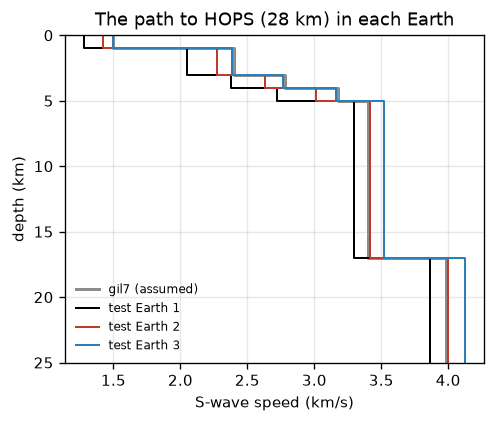

In [34]:
GIL7_LAYERS = [(0, 1, 3.20, 1.50), (1, 3, 4.50, 2.40), (3, 4, 4.80, 2.78), (4, 5, 5.51, 3.18),
               (5, 17, 6.21, 3.40), (17, 25, 6.89, 3.98), (25, 85, 7.83, 4.52)]   # top, bottom (km), Vp, Vs (km/s)
print("gil7:  " + "   ".join(f"{a}-{b} km Vs {vs:.2f}" for a, b, vp, vs in GIL7_LAYERS[:6]) + "  ...\n")
print(f"{'':30s}" + "".join(f"{s:>6s}" for s in STATIONS))
print(f"{'distance (km)':30s}" + "".join(f"{d:6.0f}" for d in DIST_W))
for e in range(3):
    print(f"{f'test Earth {e + 1}: top 5 km slower':30s}" + "".join(f"{100 * v:5.0f}%" for v in E["shallow_slowdown"][e]))
    print(f"{'            5-25 km changed':30s}" + "".join(f"{100 * v:+5.0f}%" for v in E["mid_change"][e]))

fig, ax = plt.subplots(figsize=(4.2, 3.6))
i = STATIONS.index("HOPS")
for e, col in ((None, "0.55"), (0, "k"), (1, "#c0392b"), (2, "#2980b9")):
    z, vs = [], []
    for top, bot, vp, v in GIL7_LAYERS[:-1]:
        f = 1.0 if e is None else (1 - E["shallow_slowdown"][e, i] if top < 5 else 1 + E["mid_change"][e, i])
        z += [top, bot]; vs += [v * f, v * f]
    ax.plot(vs, z, color=col, lw=1.8 if e is None else 1.2, label="gil7 (assumed)" if e is None else f"test Earth {e + 1}")
ax.set(xlabel="S-wave speed (km/s)", ylabel="depth (km)", ylim=(25, 0),
       title=f"The path to HOPS ({DIST_W[i]:.0f} km) in each Earth")
ax.legend(fontsize=7, frameon=False, loc="lower left")
fig.tight_layout()
plt.show()


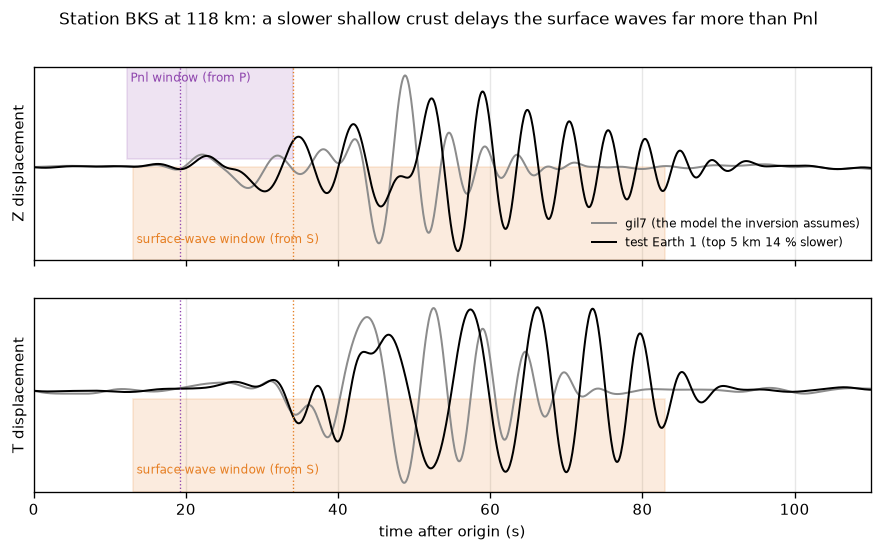

In [35]:
def synthetic(M, earth=None, noise=0.02, seed=0):
    """Three-component records at the 8 stations of a source M, made in gil7 (earth=None) or in
    one of the test Earths, with white noise of `noise` times each station's peak."""
    r = np.random.default_rng(seed)
    b = design_vector(M)
    out = []
    for i in range(8):
        g = GF[i] if earth is None else {k: E[k][earth, i] for k in KEYS}
        tr = {c: mt_design(g, AZ_W[i])[c] @ b for c in "TRZ"}
        pk = max(np.abs(v).max() for v in tr.values())
        out.append({c: v + r.normal(0, noise * pk, len(v)) for c, v in tr.items()})
    return out


M0 = 10 ** (1.5 * 5.0 + 16.1)                                         # dyne-cm, Mw 5.0
i = STATIONS.index("BKS")
t = np.arange(2048) * DT
tp, ts = TT[i]
fig, axes = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True)
for ax, comp in zip(axes, ("Z", "T")):
    for earth, col, lab in ((None, "0.55", "gil7 (the model the inversion assumes)"),
                            (0, "k", f"test Earth 1 (top 5 km {100 * E['shallow_slowdown'][0, i]:.0f} % slower)")):
        rec = synthetic(M_true * M0, earth, noise=0.0)[i][comp]
        ax.plot(t, gm.bandpass(rec, DT, 0.02, 0.2), color=col, lw=1.2, label=lab)
    if comp == "Z":
        ax.axvspan(tp - 7, ts, ymin=0.52, ymax=1, color="#8e44ad", alpha=0.15)
        ax.text(tp - 6.5, ax.get_ylim()[1] * 0.85, "Pnl window (from P)", fontsize=7, color="#8e44ad")
    ax.axvspan(ts - 21, ts + 49, ymin=0, ymax=0.48, color="#e67e22", alpha=0.15)
    ax.text(ts - 20.5, ax.get_ylim()[0] * 0.85, "surface-wave window (from S)", fontsize=7, color="#e67e22", va="bottom")
    ax.axvline(tp, color="#8e44ad", lw=0.8, ls=":"); ax.axvline(ts, color="#e67e22", lw=0.8, ls=":")
    ax.set_ylabel(f"{comp} displacement"); ax.set_yticks([])
axes[0].legend(fontsize=7, frameon=False, loc="lower right")
axes[1].set(xlabel="time after origin (s)", xlim=(0, 110))
fig.suptitle(f"Station BKS at {DIST_W[i]:.0f} km: a slower shallow crust delays the surface waves far more than Pnl", fontsize=10)
plt.show()


The first arrival, **Pnl** — the $P$ wave refracted along the base of the crust ($P_n$) and the
$P$ and converted waves reverberating in the crust behind it ($P_L$) — barely
moves: it spends little time in the slow shallow layers. The **surface waves**, which live in
those layers, arrive seconds late. A whole-trace inversion that compares the gil7 synthetic with
this record sample by sample is comparing two signals that are out of step, and least squares
will bend the mechanism to make up the difference.


### A.13 · CAP: cut the record, and let each piece slide

**Cut-and-paste** (CAP; Zhu & Helmberger 1996) is one widely used answer. It works with the three
components of motion rotated to the station: **radial** (along the path from the source), **transverse**
(across it) and **vertical**. Shear waves come in two kinds: **SH**, shaking horizontally across
the path, which lands on the transverse component alone, and **SV**, shaking in the vertical plane
of the path, which lands on the radial and vertical. At these distances the large late arrivals are
the **surface waves**: Love waves (built from SH) on the transverse, Rayleigh waves (built from SV
and P) on the radial and vertical. Four changes, each an idea you can name:

1. **Cut** each record into five windows — Pnl on the radial and vertical, and the surface waves on
   the transverse (SH), radial and vertical (SV), which is how the code names them — and filter the
   body waves at higher frequency than the surface waves.
2. **Slide each window.** For each window pair, try every time shift within a few seconds and
   keep the one where data and synthetic correlate best. The shift is a **latent variable**: a
   quantity we do not care about but must fit so that the comparison is fair. Taking the best
   correlation over all lags is the same operation as max-pooling in a neural network.
3. **Weight the windows** so that the small Pnl counts and the near stations do not dominate —
   **balancing the terms of the loss**.
4. **Search** strike, dip and rake on a grid at a fixed magnitude, and the magnitude by a line
   search: a **restricted hypothesis space** (double couples only), searched globally, so the
   misfit surface itself is the uncertainty.

The full program is in `gm.cap_station` and `gm.cap_search`. The cell below is the heart of it:
the misfit of one trial tensor with every window slid to its best lag.

The misfit of one window is $|d - s|^2$ for the record $d$ and synthetic $s = Gb$, and it expands
into three pieces that can be computed once and reused for every trial tensor $b$ and lag:

$$|d - s|^2 \;=\; \underbrace{d^\top d}_{\texttt{rec2}} \;+\; \underbrace{b^\top (G^\top G)\, b}_{\texttt{SS}}
\;-\; 2\,\underbrace{(d^\top G)\, b}_{\texttt{crl}\text{, at each lag}} .$$

Only the last depends on the lag, so sliding the window means taking its largest value.


In [36]:
def cap_misfit_simple(stations, b):
    """CAP's misfit of one trial tensor b (design convention and units). Each station has five
    windows (SH, SV-radial, SV-vertical, Pnl-radial, Pnl-vertical) holding the data energy `rec2`,
    the synthetic basis's Gram matrix `SS`, and the correlation of data and each synthetic column
    at every lag `crl`. The three surface-wave windows share one lag, the two Pnl windows another."""
    total = 0.0
    for win in stations:
        corr = [w["crl"] @ b for w in win]                     # data . synthetic, at every lag
        syn2 = [b @ w["SS"] @ b for w in win]                  # |synthetic|^2
        for group in ((0, 1, 2), (3, 4)):
            lag = np.argmax(sum(corr[j] for j in group))       # the best shift for this group
            total += sum(win[j]["rec2"] + syn2[j] - 2 * corr[j][lag] for j in group)
    return total


def cap_windows(data, shifts=True):
    """The published CAP's windows for the 8 stations: Pnl 0.05-0.2 Hz and +-2 s, surface waves
    0.02-0.1 Hz and +-4 s (or no shifts at all)."""
    return [gm.cap_station(GF[i], data[i], AZ_W[i], DIST_W[i], DT, band=((0.05, 0.2), (0.02, 0.1)),
                           tp=TT[i][0], ts=TT[i][1], pnl_shift=2.0 if shifts else 0.0,
                           surf_shift=4.0 if shifts else 0.0) for i in range(8)]


#### Does the sliding repair a wrong velocity model?

Now the test the whole section has been building to. Plant this earthquake's mechanism, make its
records at the eight stations with 2 % noise — once in gil7 itself, and once in each of the three
test Earths. Then invert every set of records with gil7's Green's functions
three ways:

- **TDMT**: least squares on the whole trace, every sample of every component, at 0.02–0.1 Hz;
- **CAP with its shifts turned off**: the same windows, bands and weights as CAP, no sliding;
- **CAP**.

The middle one is the control. It differs from CAP only in the sliding, so comparing the two
isolates what the shifts do.


In [37]:
def tdmt(data, band=(0.02, 0.1)):
    """Whole-trace least squares over every sample of every component at the 8 stations, no shifts.
    Returns the north-east-down tensor (the inverse of `design_vector`)."""
    rows, d = [], []
    for i in range(8):
        D = mt_design(GF[i], AZ_W[i])
        for c in "TRZ":
            rows.append(gm.bandpass(D[c], DT, *band, axis=0))
            d.append(gm.bandpass(data[i][c], DT, *band))
    b = np.linalg.lstsq(np.vstack(rows), np.concatenate(d), rcond=None)[0]
    return -1e20 * np.array([[b[0], b[2], b[3]], [b[2], b[1], b[4]], [b[3], b[4], b[5]]])


def cap(data, shifts=True):
    """CAP's grid search (coarse, then a 2-degree refinement around the best) and Mw line search."""
    st = cap_windows(data, shifts)
    r = gm.cap_search(st, 5.0, 0.1)
    s0 = r["sdr"]
    r = gm.cap_search(st, r["mw"], 0.0, sdr=gm.dc_grid((s0[0] - 10, s0[0] + 10, 2), (max(s0[1] - 10, 1), min(s0[1] + 10, 90), 2),
                                                       (s0[2] - 10, s0[2] + 10, 2)))
    return sdr_to_mt(*r["sdr"])


print("Kagan angle to the planted mechanism (°):")
print(f"{'records made in':>28s}   TDMT   CAP, shifts off   CAP")
for earth, name in ((None, "gil7 (the assumed Earth)"), (0, "test Earth 1"), (1, "test Earth 2"), (2, "test Earth 3")):
    data = synthetic(M_true * M0, earth=earth, noise=0.02)
    print(f"{name:>28s}  {kagan(tdmt(data), M_true):5.1f}   {kagan(cap(data, False), M_true):10.1f}      {kagan(cap(data), M_true):5.1f}")


Kagan angle to the planted mechanism (°):
             records made in   TDMT   CAP, shifts off   CAP


    gil7 (the assumed Earth)    2.7          3.2        3.2


                test Earth 1    8.5         17.2        1.6


                test Earth 2    8.5          5.2        3.2


                test Earth 3   23.3         25.2        5.8


In the Earth the inversion assumes, all three recover the mechanism to within a few degrees: with
the right Green's functions, cutting and sliding buy nothing. In every test Earth, CAP stays within
a few degrees while whole-trace TDMT drifts by up to tens of degrees — and **CAP with its shifts
turned off drifts too**, in two of the three Earths farther than TDMT. So it is the sliding that
repairs the wrong velocity model, not the windows or the weights. The shift is a nuisance variable, fitted so that the comparison of data and synthetic
is made at the right time; fitting it is what lets a wrong model give a right answer.

This is one planted mechanism, chosen because it is the real earthquake's. Part B repeats the test
on many planted mechanisms, in a twin of that earthquake's records, before trusting what CAP says
about the real ones.


## What Part B does with these methods

**[Part B](https://colab.research.google.com/github/AI4EPS/EPS207_Observational_Seismology/blob/main/docs/notebooks/03b_focal_mw5.ipynb)**
takes the same methods to real data. It works one earthquake in depth — the Mw 5.0 of 14 December
2016, the largest in the field's catalogue window, whose first-motion mechanism and waveform moment
tensors disagree by some sixty degrees. For each data type it starts from the real records, builds a
**twin** of that earthquake whose truth we set (the same rays, the same stations, reading errors
measured from the real data) to see what each method can and cannot recover, and then returns to
the real records to read the answer.

## What to take away

### Machine learning

- A problem linear in its unknowns is a design matrix whatever the unknowns mean, and the same matrix gives a regression (amplitudes, seismograms) and a classification (first motions, their signs).
- The singular value decomposition shows which combinations of the unknowns the data determine, and the resolution matrix shows the answer as a blurred truth before any data are collected.
- Damping trades variance for bias: its error splits exactly into the two, and it helps only where the design matrix is ill conditioned.
- When many models fit the labels, the centre of that set is a better answer than any single member, and searching a larger hypothesis space and projecting afterwards is worse still.
- A loss is a claim about the noise: the 0–1 and FPFIT losses must be searched on a grid, while hinge and logistic losses are convex and reward a margin.
- An error bar must include the errors in the inputs to contain the truth; perturbing the inputs and pooling the answers (HASH) is data augmentation and an ensemble at once.
- A nuisance variable such as a time shift is fitted, window by window, against the model being tested (CAP).

### Seismology

- A moment tensor is six numbers; the P amplitude is $\gamma^\top M\gamma$, a seismogram is a sum of Green's functions weighted by the same six, and a first motion is the sign of the amplitude, so it gives a mechanism but never a moment.
- The vertical component of a shallow source is the worst-resolved part of the tensor, because rays to stations far away compared with its depth leave it nearly horizontally.
- FPFIT, HASH, TDMT and CAP are the programs behind the network's catalogues; each is a few dozen lines of numpy once the bookkeeping is set aside, and each improved on its predecessor by modelling one more source of error.
- A wrong velocity model delays surface waves more than Pnl, which is why CAP cuts the record and lets each piece slide.